# Python literary analysis

This is an exploratory notebook, document the steps taken to begin digital literary analysis:
- Setting up the corpus
- Preparing the text
- Tokenization and lemmatization
- Running basic statistics
- Word frequency analysis
- Beginning visualization

## 1. assemble the corpus

Assembling a corpus is a somewhat tedious first step in any type of digital literary analysis. I used [Project Gutenberg](https://www.gutenberg.org/). The process I use is to find the book I want. Then under "Other formats & older devices", select "Plain Text (accessible)". This opens the plain text in the web browser. I click into the window, use the "select all" shortcut, then the "copy" shortcut. Then I open a text editor. For this purpose I use Sublime, but any text editor will do. Then I use the "paste" shortcut and save the file with a `.txt` file ending. 

For this project, I assembled a corpus of works by Mary Wollstonecraft, Mary Shelley, and Jane Austen.

## 2. Import, inspect, split

The next step is to begin developing tools for analyzing the text. The text needs to be imported into the Python environment, in this case a Jupyter Notebook. Then it will have to be cleaned and organized in the way I want. This depends on the intended analysis. Many digital literary scholars use the entire text at once, or split it into arbitrary equal pieces. I prefer to begin my analysis with the author's own division into chapters, since I find that authors tend to build a certain conceptual or thematic unity into these divisions that gets lost if they are ignored in analysis. Other times, it may be necessary to split to the paragraph level, or analyze the whole work at once. 

This code opens Wollstonecraft's novel "Maria", reads it into memory, and saves the text as a variable called `maria`.

In [1]:
with open('../corpuses/wollstonecraft-corpus/maria.txt') as m:
    maria = m.read()

Next, I inspect the text. This code tells Python to display the first 2000 characters of the text.

In [2]:
print(maria[:2000])

The Project Gutenberg eBook of Maria; Or, The Wrongs of Woman
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Maria; Or, The Wrongs of Woman

Author: Mary Wollstonecraft


        
Release date: March 8, 2006 [eBook #134]
                Most recently updated: October 29, 2024

Language: English

Other information and formats: www.gutenberg.org/ebooks/134

Credits: Judith Boss and David Widger


*** START OF THE PROJECT GUTENBERG EBOOK MARIA; OR, THE WRONGS OF WOMAN ***

MARIA

or
The Wrongs of Woman

by MARY WOLLSTONECRAFT


(1759-1797)

After the edition of 1798




CONTENTS

 MARIA


I can see that it has Project Gutenberg's boilerplate disclaimers and licensing information at the beginning. We need to clean this up before we can analyze the original text. To this end, I've developed a *Python method* that removes the Project Gutenberg boilerplate from the beginning and end. 

This and almost all subsequent methods were created with assistance from Large Language Models ("AI"). 

In [3]:
import re

def clean_gutenberg_text(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    start_pattern = r"\*\*\*\s*START OF.*?\*\*\*"
    end_pattern = r"\*\*\*\s*END OF.*?\*\*\*"

    start_match = re.search(start_pattern, text, re.DOTALL | re.IGNORECASE)
    end_match = re.search(end_pattern, text, re.DOTALL | re.IGNORECASE)

    if not start_match or not end_match:
        raise ValueError("Could not locate Gutenberg boundaries.")

    cleaned = text[start_match.end():end_match.start()]

    return cleaned.strip()

In [4]:
# clean the text and store the cleaned text in the same variable
maria = clean_gutenberg_text('../corpuses/wollstonecraft-corpus/maria.txt')

Now I want to inspect the result and double-check my results. I also want to peek at the way it's structured. I'll use regularities in the way chapters are marked to split the text.

In [5]:
print(maria[:10000])

MARIA

or
The Wrongs of Woman

by MARY WOLLSTONECRAFT


(1759-1797)

After the edition of 1798




CONTENTS

 MARIA
 PREFACE
 AUTHOR’S PREFACE
 CHAPTER 1
 CHAPTER 2
 CHAPTER 3
 CHAPTER 4
 CHAPTER 5
 CHAPTER 6
 CHAPTER 7
 CHAPTER 8
 CHAPTER 9
 CHAPTER 10
 CHAPTER 11
 CHAPTER 12
 CHAPTER 13
 CHAPTER 14
 APPENDIX
 CHAPTER 15
 CHAPTER 16
 CHAPTER 17
 CONCLUSION




MARIA

or

The Wrongs of Woman




PREFACE


The public are here presented with the last literary attempt of an
author, whose fame has been uncommonly extensive, and whose talents
have probably been most admired, by the persons by whom talents are
estimated with the greatest accuracy and discrimination. There are few,
to whom her writings could in any case have given pleasure, that would
have wished that this fragment should have been suppressed, because it
is a fragment. There is a sentiment, very dear to minds of taste and
imagination, that finds a melancholy delight in contemplating these
unfinished productions of genius, the

I can see that the project Gutenberg text has a CONTENTS section near the beginning, that lists the names of all the chapters or other sections like prefaces, introductions, and appendices. I use a regular expression to locate and analyze this contents section, then search through the text for the places where those sections begin and end. I split the text in those locations and store each chunk of text as an entry in a dictionary. This is a data structure consisting of key value pairs:

example_dictionary = {
    'key1': value1,
    'key2': value2,
    'key3': value3
    }

In this case, I'm going to have a dictionary in which the keys are the titles of the chapters or other sections, and the values are the contents of each chapter.

In [6]:
import re

def split_by_contents(text):
    """
    Split a Gutenberg text into sections using its CONTENTS page.

    Returns:
        dict[str, str]
    """

    # Find CONTENTS section
    contents_match = re.search(
        r"\n\s*CONTENTS\s*\n",
        text,
        re.IGNORECASE
    )

    if not contents_match:
        raise ValueError("Could not find CONTENTS section.")

    contents_start = contents_match.end()

    # Everything after CONTENTS
    remainder = text[contents_start:]

    lines = remainder.splitlines()

    titles = []
    first_title_pos = None

    # Collect non-blank lines until we encounter
    # the first title repeated in the body.
    for i, line in enumerate(lines):
        stripped = line.strip()

        if not stripped:
            continue

        titles.append(stripped)

        # Look ahead: if this title appears later surrounded
        # by blank lines, we've probably reached the body.
        pattern = (
            r"\n\s*\n\s*"
            + re.escape(stripped)
            + r"\s*\n"
        )

        m = re.search(pattern, remainder)

        if m and m.start() > 0:
            first_title_pos = m.start()
            break

    if first_title_pos is None:
        raise ValueError("Could not determine end of CONTENTS section.")

    contents_text = remainder[:first_title_pos]
    titles = [
        line.strip()
        for line in contents_text.splitlines()
        if line.strip()
    ]

    body = remainder[first_title_pos:]

    # Locate each title in the body
    sections = []

    for title in titles:
        pattern = (
            r"\n\s*\n\s*"
            + re.escape(title)
            + r"\s*\n"
        )

        m = re.search(pattern, body)

        if m:
            sections.append((title, m.start()))

    if not sections:
        raise ValueError("No section headings found in body.")

    # Slice text into sections
    result = {}

    for i, (title, start) in enumerate(sections):
        if i + 1 < len(sections):
            end = sections[i + 1][1]
        else:
            end = len(body)

        result[title] = body[start:end].strip()

    return result

Now I run the method on my raw text of the novel. Then I inspect the resulting dictionary's keys using the `.keys()` method. Then I inspect the resulting text for one chapter.

In [7]:
maria_contents = split_by_contents(maria)

In [8]:
maria_contents.keys()

dict_keys(['MARIA', 'PREFACE', 'AUTHOR’S PREFACE', 'CHAPTER 1', 'CHAPTER 2', 'CHAPTER 3', 'CHAPTER 4', 'CHAPTER 5', 'CHAPTER 6', 'CHAPTER 7', 'CHAPTER 8', 'CHAPTER 9', 'CHAPTER 10', 'CHAPTER 11', 'CHAPTER 12', 'CHAPTER 13', 'CHAPTER 14', 'APPENDIX', 'CHAPTER 15', 'CHAPTER 16', 'CHAPTER 17', 'CONCLUSION'])

In [9]:
maria_contents['CHAPTER 1']

'CHAPTER 1\n\n\nAbodes of horror have frequently been described, and castles, filled\nwith spectres and chimeras, conjured up by the magic spell of genius to\nharrow the soul, and absorb the wondering mind. But, formed of such\nstuff as dreams are made of, what were they to the mansion of despair,\nin one corner of which Maria sat, endeavouring to recall her scattered\nthoughts!\n\nSurprise, astonishment, that bordered on distraction, seemed to have\nsuspended her faculties, till, waking by degrees to a keen sense of\nanguish, a whirlwind of rage and indignation roused her torpid pulse.\nOne recollection with frightful velocity following another, threatened\nto fire her brain, and make her a fit companion for the terrific\ninhabitants, whose groans and shrieks were no unsubstantial sounds of\nwhistling winds, or startled birds, modulated by a romantic fancy,\nwhich amuse while they affright; but such tones of misery as carry a\ndreadful certainty directly to the heart. What effect must

We still have a lot of cleanup to do. Those `\n` characters are Project Gutenberg's newline characters. They equalize every line to 70 characters in width, which is not ideal for digital text analysis. We're going to remove the newlines.

Paragraph divisions are marked by double newline characters. Paragraphs are artifacts of the original author's work and we may at some point want to analyze them, so I'll split the cleanup in two separate parts. First, I develop a method to just take out the Gutenberg newlines.

In [10]:
import re

def unwrap_gutenberg_paragraphs(text):
    """
    Remove Gutenberg line wrapping while preserving paragraphs.
    """

    # Normalize line endings
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # Split into paragraphs
    paragraphs = re.split(r"\n\s*\n+", text)

    cleaned = []

    for para in paragraphs:
        # Replace internal newlines with spaces
        para = re.sub(r"\s*\n\s*", " ", para)

        # Collapse repeated spaces
        para = re.sub(r"\s+", " ", para)

        cleaned.append(para.strip())

    return "\n\n".join(cleaned)

Now I'm going to loop over the contents of the dictionary created earlier, and for each chapter text, apply the cleanup. Then I'll inspect the result.

In [11]:
maria_contents = {
    title: unwrap_gutenberg_paragraphs(text)
    for title, text in maria_contents.items()
}

In [12]:
maria_contents['CHAPTER 1']

'CHAPTER 1\n\nAbodes of horror have frequently been described, and castles, filled with spectres and chimeras, conjured up by the magic spell of genius to harrow the soul, and absorb the wondering mind. But, formed of such stuff as dreams are made of, what were they to the mansion of despair, in one corner of which Maria sat, endeavouring to recall her scattered thoughts!\n\nSurprise, astonishment, that bordered on distraction, seemed to have suspended her faculties, till, waking by degrees to a keen sense of anguish, a whirlwind of rage and indignation roused her torpid pulse. One recollection with frightful velocity following another, threatened to fire her brain, and make her a fit companion for the terrific inhabitants, whose groans and shrieks were no unsubstantial sounds of whistling winds, or startled birds, modulated by a romantic fancy, which amuse while they affright; but such tones of misery as carry a dreadful certainty directly to the heart. What effect must they then have

That still leaves the double new-lines that mark paragraphs. We may want to keep those and do paragraph level analysis at some point. But, for much of what I want to do right now, they would get in the way. So I develop a method to clear all those out and normalize the spaces. At this point I am modifying the original work by eliminating a level of structure that the author intended.

Afterwards, I run the method on the dictionary and inspect the results.

In [13]:
def normalize_whitespace(text):
    """
    Convert all whitespace (spaces, tabs, newlines)
    into single spaces.
    """
    return " ".join(text.split())

In [14]:
maria_contents = {
    title: normalize_whitespace(text)
    for title, text in maria_contents.items()
}

In [15]:
maria_contents['CHAPTER 1']

'CHAPTER 1 Abodes of horror have frequently been described, and castles, filled with spectres and chimeras, conjured up by the magic spell of genius to harrow the soul, and absorb the wondering mind. But, formed of such stuff as dreams are made of, what were they to the mansion of despair, in one corner of which Maria sat, endeavouring to recall her scattered thoughts! Surprise, astonishment, that bordered on distraction, seemed to have suspended her faculties, till, waking by degrees to a keen sense of anguish, a whirlwind of rage and indignation roused her torpid pulse. One recollection with frightful velocity following another, threatened to fire her brain, and make her a fit companion for the terrific inhabitants, whose groans and shrieks were no unsubstantial sounds of whistling winds, or startled birds, modulated by a romantic fancy, which amuse while they affright; but such tones of misery as carry a dreadful certainty directly to the heart. What effect must they then have produ

# Tokenize

With the text reasonably cleaned and split the way I want it, I can start to use some natural language processing (NLP) tools. I will use the `spacy` library. I will use the large English language model since this includes semantic analysis data, which I may want to use later on.

In [16]:
import spacy

In [17]:
nlp = spacy.load('en_core_web_lg')

Now I'm going to take the raw text and *tokenize* it. This will go through all the words and convert them into NLP *tokens*. A token is a digital representation of a word that contains a huge amount of information based on the language model. 

In [18]:
maria_tokens = {
    title: nlp(text)
    for title, text in maria_contents.items()
}

In [19]:
maria_tokens.keys()

dict_keys(['MARIA', 'PREFACE', 'AUTHOR’S PREFACE', 'CHAPTER 1', 'CHAPTER 2', 'CHAPTER 3', 'CHAPTER 4', 'CHAPTER 5', 'CHAPTER 6', 'CHAPTER 7', 'CHAPTER 8', 'CHAPTER 9', 'CHAPTER 10', 'CHAPTER 11', 'CHAPTER 12', 'CHAPTER 13', 'CHAPTER 14', 'APPENDIX', 'CHAPTER 15', 'CHAPTER 16', 'CHAPTER 17', 'CONCLUSION'])

Here I'm going to take the preface, which is relatively short, and inspect some of the token information. I am going to go through all the tokens in the preface and dispaly the token's text content, what *part of speech* it is, and the *syntactic dependency relation*. These are abbreviations that are standardized across NLP libraries. You can look at the list of [NLP part of speech labels](https://www.pythonprog.com/spacy-part-of-speech-tags/) and [dependency labels](https://github.com/clir/clearnlp-guidelines/blob/master/md/specifications/dependency_labels.md).

In [20]:
for token in maria_tokens['PREFACE']:
    print(token.text, token.pos_, token.dep_)

PREFACE PROPN npadvmod
The DET det
public NOUN nsubjpass
are AUX auxpass
here ADV advmod
presented VERB ROOT
with ADP prep
the DET det
last ADJ amod
literary ADJ amod
attempt NOUN pobj
of ADP prep
an DET det
author NOUN pobj
, PUNCT punct
whose DET poss
fame NOUN nsubj
has AUX aux
been AUX relcl
uncommonly ADV advmod
extensive ADJ acomp
, PUNCT punct
and CCONJ cc
whose DET poss
talents NOUN nsubjpass
have AUX aux
probably ADV advmod
been AUX auxpass
most ADV advmod
admired VERB conj
, PUNCT punct
by ADP agent
the DET det
persons NOUN pobj
by ADP prep
whom PRON pobj
talents NOUN nsubjpass
are AUX auxpass
estimated VERB relcl
with ADP prep
the DET det
greatest ADJ amod
accuracy NOUN pobj
and CCONJ cc
discrimination NOUN conj
. PUNCT punct
There PRON expl
are VERB ccomp
few ADJ attr
, PUNCT punct
to PART prep
whom PRON pobj
her PRON poss
writings NOUN nsubj
could AUX aux
in ADP prep
any DET det
case NOUN pobj
have AUX aux
given VERB relcl
pleasure NOUN dobj
, PUNCT punct
that PRON nsubj
w

Here's a slightly prettier output:

In [21]:
for token in maria_tokens['PREFACE']:
    print(f'{token.text:15}{token.pos_:10}{spacy.explain(token.pos_)}')

PREFACE        PROPN     proper noun
The            DET       determiner
public         NOUN      noun
are            AUX       auxiliary
here           ADV       adverb
presented      VERB      verb
with           ADP       adposition
the            DET       determiner
last           ADJ       adjective
literary       ADJ       adjective
attempt        NOUN      noun
of             ADP       adposition
an             DET       determiner
author         NOUN      noun
,              PUNCT     punctuation
whose          DET       determiner
fame           NOUN      noun
has            AUX       auxiliary
been           AUX       auxiliary
uncommonly     ADV       adverb
extensive      ADJ       adjective
,              PUNCT     punctuation
and            CCONJ     coordinating conjunction
whose          DET       determiner
talents        NOUN      noun
have           AUX       auxiliary
probably       ADV       adverb
been           AUX       auxiliary
most           ADV       adverb

## Basic Corpus Statistics

Now I'm ready to create a table with some statistical information. Here, I'm running through the dictionary of tokenized texts and creating a table that contains a bunch of data. I want to know how many tokens there are. This is basically how many words and punctuation marks there are. Then I want to know how many of those are distinct words. This gives us what is called the *type-token ratio*, which is a standard corpus analytic stat. It basically says what proportion of unique words to total words the author uses.

With that calculated, I then calculate the totals of each part of speech. This will eventually allow me to do stuff like calculate the percentage of adverbs, adjectives, pronouns, and other parts of speech if I want to. There are some other standard stylometric statistics, like average word length that would normally be calculated here. This is also where average words per paragraph would be calculated. I will be doing this later when I compare works. For now I'm just testing stuff out. I won't actually be using this at this stage.

In [22]:
from collections import Counter
import pandas as pd

rows = []

for title, doc in maria_tokens.items():

    token_count = len(doc)

    # Unique token texts
    type_count = len(set(token.text for token in doc))

    # POS counts
    pos_counts = Counter(token.pos_ for token in doc)

    row = {
        "section": title,
        "tokens": token_count,
        "types": type_count,
        "type_token_ratio": type_count / token_count if token_count else 0
    }

    row.update(pos_counts)

    rows.append(row)

stats_df = pd.DataFrame(rows).fillna(0)

# Optional: sort columns
fixed_cols = ["section", "tokens", "types", "type_token_ratio"]
other_cols = sorted(
    c for c in stats_df.columns
    if c not in fixed_cols
)

stats_df = stats_df[fixed_cols + other_cols]

stats_df

,section,tokens,types,type_token_ratio,ADJ,ADP,ADV,AUX,CCONJ,DET,...,NOUN,NUM,PART,PRON,PROPN,PUNCT,SCONJ,SYM,VERB,X
0,MARIA,6,6,1.000000,0.0,1,0.0,0.0,1,1,...,0.0,0.0,0.0,0.0,3,0.0,0.0,0.0,0.0,0.0
1,PREFACE,533,255,0.478424,34.0,63,22.0,41.0,17,70,...,96.0,5.0,15.0,37.0,6,56.0,10.0,0.0,54.0,7.0
2,AUTHOR’S PREFACE,480,239,0.497917,28.0,61,17.0,33.0,16,51,...,95.0,0.0,17.0,38.0,4,65.0,5.0,0.0,49.0,1.0
3,CHAPTER 1,2536,957,0.377366,158.0,278,114.0,144.0,85,234,...,455.0,9.0,84.0,229.0,24,340.0,60.0,0.0,321.0,0.0
4,CHAPTER 2,3964,1255,0.316599,255.0,421,153.0,176.0,139,352,...,653.0,22.0,122.0,389.0,74,590.0,103.0,0.0,507.0,3.0
5,CHAPTER 3,3013,1095,0.363425,188.0,359,126.0,127.0,101,267,...,533.0,9.0,100.0,320.0,52,405.0,52.0,0.0,363.0,11.0
6,CHAPTER 4,1552,635,0.409149,95.0,174,77.0,72.0,57,124,...,278.0,9.0,44.0,154.0,28,227.0,28.0,0.0,184.0,0.0
7,CHAPTER 5,8113,1970,0.242820,397.0,909,278.0,434.0,253,666,...,1357.0,36.0,284.0,996.0,42,1236.0,179.0,0.0,1036.0,3.0
8,CHAPTER 6,1590,623,0.391824,95.0,174,54.0,59.0,47,141,...,275.0,3.0,57.0,185.0,41,215.0,37.0,0.0,205.0,0.0
9,CHAPTER 7,4980,1410,0.283133,294.0,501,195.0,250.0,156,379,...,843.0,26.0,202.0,614.0,73,731.0,90.0,0.0,616.0,2.0


I will now turn that code into a reusable method so I can run it on other materials. I will just make a couple of adjustments. First, I won't count punctuation as a token or type. Second, I will add a lemma count. A *lemma* is the base form of a word. If we just count *types*, this counts "walk", "walking", and "walked" as different types. However they are all variants of the same lemma. This gives us a more accurate measure of the unique individual words the author uses. We will circle back to this and add some more statistics at a later time.

In [23]:
from collections import Counter
import pandas as pd

def document_statistics(doc_dict):
    """
    Generate corpus statistics for a dictionary of SpaCy Docs.

    Parameters
    ----------
    doc_dict : dict
        Dictionary of the form:
        {
            "title1": spacy_doc,
            "title2": spacy_doc,
            ...
        }

    Returns
    -------
    pandas.DataFrame
    """

    rows = []

    for title, doc in doc_dict.items():

        words = [token for token in doc if not token.is_punct]

        token_count = len(words)

        type_count = len(
            set(token.text.lower() for token in words)
        )

        lemma_count = len(
            set(token.lemma_.lower() for token in words)
        )

        pos_counts = Counter(
            token.pos_ for token in words
        )

        row = {
            "section": title,
            "tokens": token_count,
            "types": type_count,
            "lemmas": lemma_count,
            "type_token_ratio":
                type_count / token_count if token_count else 0
        }

        row.update(pos_counts)

        rows.append(row)

    df = pd.DataFrame(rows).fillna(0)

    fixed_cols = [
        "section",
        "tokens",
        "types",
        "lemmas",
        "type_token_ratio"
    ]

    other_cols = sorted(
        c for c in df.columns
        if c not in fixed_cols
    )

    return df[fixed_cols + other_cols]

In [24]:
document_statistics(maria_tokens)

,section,tokens,types,lemmas,type_token_ratio,ADJ,ADP,ADV,AUX,CCONJ,...,INTJ,NOUN,NUM,PART,PRON,PROPN,PUNCT,SCONJ,VERB,X
0,MARIA,6,6,6,1.000000,0.0,1,0.0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,3,0.0,0.0,0.0,0.0
1,PREFACE,472,243,222,0.514831,34.0,63,22.0,41.0,17,...,0.0,96.0,5.0,15.0,37.0,6,0.0,10.0,54.0,2.0
2,AUTHOR’S PREFACE,414,222,214,0.536232,28.0,61,17.0,33.0,16,...,0.0,95.0,0.0,17.0,38.0,4,0.0,5.0,49.0,0.0
3,CHAPTER 1,2197,922,855,0.419663,158.0,278,114.0,144.0,85,...,1.0,455.0,9.0,84.0,229.0,24,1.0,60.0,321.0,0.0
4,CHAPTER 2,3370,1195,1058,0.354599,255.0,421,153.0,176.0,139,...,5.0,652.0,22.0,122.0,389.0,74,0.0,103.0,506.0,1.0
5,CHAPTER 3,2597,1050,948,0.404313,188.0,359,126.0,127.0,101,...,0.0,533.0,9.0,100.0,320.0,52,0.0,52.0,362.0,1.0
6,CHAPTER 4,1325,611,567,0.461132,95.0,174,77.0,72.0,57,...,1.0,278.0,9.0,44.0,154.0,28,0.0,28.0,184.0,0.0
7,CHAPTER 5,6873,1890,1612,0.274989,397.0,909,278.0,434.0,253,...,7.0,1357.0,36.0,284.0,995.0,42,0.0,179.0,1036.0,0.0
8,CHAPTER 6,1375,601,558,0.437091,95.0,174,54.0,59.0,47,...,2.0,275.0,3.0,57.0,185.0,41,0.0,37.0,205.0,0.0
9,CHAPTER 7,4247,1357,1201,0.319520,294.0,501,195.0,250.0,156,...,8.0,842.0,26.0,202.0,614.0,73,0.0,90.0,616.0,1.0


## Analyzing a single text: Maria

### Word frequency analysis

Now I want to look at some measures of word frequency and what they tell us about the work we are currently looking at, "Maria" by Mary Wollstonecraft. First, we are going to do simple word frequency analysis. The following code looks through the tokenized texts of the chapters in Maria. It looks at lemmas, not raw tokens. It excludes *stop words*, which are the most common words in the English language and generally considered statistical noise. It also ignores punctuation, and anything that spacy identifies as an *entity*: people, places, and organizations. Spacy's entity recognition is not perfect, but it's pretty good and very helpful.

In [25]:
from collections import Counter

for title, doc in maria_tokens.items():
    freqs = Counter(token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.ent_type_)
    commonest = freqs.most_common(10)
    print(commonest)

[('Wrongs', 1), ('Woman', 1)]
[('author', 7), ('public', 3), ('give', 3), ('manner', 3), ('editor', 3), ('preface', 3), ('present', 2), ('talent', 2), ('wish', 2), ('fragment', 2)]
[('woman', 6), ('wrong', 4), ('mind', 3), ('author', 2), ('like', 2), ('sketch', 2), ('fancy', 2), ('delineation', 2), ('heart', 2), ('novel', 2)]
[('mind', 9), ('mother', 6), ('life', 6), ('long', 6), ('render', 5), ('time', 5), ('woman', 5), ('endeavour', 4), ('faculty', 4), ('sense', 4)]
[('heart', 13), ('think', 11), ('mind', 10), ('eye', 8), ('read', 7), ('thought', 7), ('book', 7), ('escape', 7), ('till', 7), ('imagination', 6)]
[('like', 8), ('woman', 7), ('mind', 6), ('eye', 6), ('country', 6), ('write', 5), ('till', 5), ('life', 5), ('passion', 5), ('man', 5)]
[('love', 7), ('mind', 6), ('feel', 6), ('emotion', 5), ('give', 4), ('heart', 4), ('imagination', 4), ('long', 4), ('draw', 4), ('happy', 4)]
[('house', 18), ('mother', 15), ('poor', 15), ('child', 14), ('till', 13), ('say', 12), ('time', 12)

That seems very interesting and useful. Before moving on, I'll have an LLM generate a reusable method that returns the result so it can be stored as a variable.

In [26]:
from collections import Counter

def chapter_top_words(
    token_dict,
    top_n=10,
    remove_stopwords=True,
    remove_punct=True,
    remove_entities=True,
    lowercase=True
):
    """
    Generate top-N word lists for each chapter.

    Parameters
    ----------
    token_dict : dict[str, spacy.Doc]

    top_n : int
        Number of most frequent words to return.

    Returns
    -------
    dict
        {
            chapter: [
                (word, frequency),
                ...
            ]
        }
    """

    results = {}

    for chapter, doc in token_dict.items():

        freqs = Counter()

        for token in doc:

            if remove_stopwords and token.is_stop:
                continue

            if remove_punct and token.is_punct:
                continue

            if remove_entities and token.ent_type_:
                continue

            lemma = token.lemma_

            if lowercase:
                lemma = lemma.lower()

            freqs[lemma] += 1

        results[chapter] = freqs.most_common(top_n)

    return results

maria_top_10_each_chapter = chapter_top_words(maria_tokens)

maria_top_10_each_chapter

{'MARIA': [('wrongs', 1), ('woman', 1)],
 'PREFACE': [('author', 7),
  ('preface', 4),
  ('public', 3),
  ('give', 3),
  ('manner', 3),
  ('editor', 3),
  ('present', 2),
  ('talent', 2),
  ('wish', 2),
  ('fragment', 2)],
 'AUTHOR’S PREFACE': [('woman', 7),
  ('wrong', 4),
  ('mind', 3),
  ('author', 2),
  ('like', 2),
  ('sketch', 2),
  ('fancy', 2),
  ('delineation', 2),
  ('heart', 2),
  ('novel', 2)],
 'CHAPTER 1': [('mind', 9),
  ('mother', 6),
  ('life', 6),
  ('long', 6),
  ('render', 5),
  ('time', 5),
  ('woman', 5),
  ('endeavour', 4),
  ('faculty', 4),
  ('sense', 4)],
 'CHAPTER 2': [('heart', 13),
  ('think', 11),
  ('mind', 10),
  ('eye', 8),
  ('read', 7),
  ('thought', 7),
  ('book', 7),
  ('escape', 7),
  ('till', 7),
  ('imagination', 6)],
 'CHAPTER 3': [('like', 8),
  ('woman', 7),
  ('mind', 6),
  ('eye', 6),
  ('country', 6),
  ('write', 5),
  ('till', 5),
  ('life', 5),
  ('passion', 5),
  ('man', 5)],
 'CHAPTER 4': [('love', 7),
  ('mind', 6),
  ('feel', 6),
  ('

Now, I'm going to go through the same data, but this time I'm going to get the 20 terms that most frequently appear on the lists above, that is the words that most frequently appear on lists of a chapter's most common words.

In [27]:
from collections import Counter

top10_presence = Counter()

for title, doc in maria_tokens.items():

    freqs = Counter(
        token.lemma_.lower()
        for token in doc
        if (
            not token.is_stop
            and not token.is_punct
            and not token.ent_type_
        )
    )

    top10_terms = {
        lemma
        for lemma, count in freqs.most_common(10)
    }

    top10_presence.update(top10_terms)

print(top10_presence.most_common(20))

[('woman', 11), ('heart', 9), ('mind', 9), ('child', 9), ('man', 7), ('eye', 6), ('think', 6), ('husband', 6), ('mother', 5), ('life', 5), ('leave', 5), ('till', 4), ('feel', 4), ('love', 4), ('house', 4), ('know', 4), ('uncle', 4), ('give', 3), ('wish', 3), ('author', 3)]


These results certainly let us see some of the themes and topics that Wollstonecraft wove into this novel. We should keep in mind that it would probably be better to calculate frequency relative to chapter length, rather than raw frequencies. However, I feel like there is some value in looking at raw frequencies too.

### TF-IDF

Next we'll look at a somewhat more advanced measure of word importance, [term frequency - inverse document frequency](https://en.wikipedia.org/wiki/Tf%E2%80%93idf) or TF-IDF. This statistic starts out with term frequency, just like we did here. Rather than absolute frequency, it uses a measure of relative frequency. Then it computes inverse document frequency. This is a measure of how many documents in a corpus contain a particular word. Words that are unique to just a few documents rank higher than words that are common to many documents. The two values (TF and IDF) are then multiplied to derive a measure of the most important words for any given document. 

Here is a method to find the top 10 words by TF-IDF score in each chapter.

In [28]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def chapter_tfidf(token_dict, top_n=10):
    """
    Compute TF-IDF scores for a dictionary of SpaCy Docs.

    Parameters
    ----------
    token_dict : dict
        {
            "CHAPTER 1": spacy_doc,
            "CHAPTER 2": spacy_doc,
            ...
        }

    top_n : int
        Number of top TF-IDF terms to return per chapter.

    Returns
    -------
    dict
        {
            "CHAPTER 1": [
                ("woman", 0.284),
                ("child", 0.263),
                ...
            ],
            ...
        }
    """

    # Build processed corpus
    processed_docs = {}

    for title, doc in token_dict.items():

        processed_docs[title] = " ".join(
            token.lemma_.lower()
            for token in doc
            if (
                not token.is_stop
                and not token.is_punct
                and not token.ent_type_
            )
        )

    # TF-IDF
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(processed_docs.values())

    feature_names = vectorizer.get_feature_names_out()
    tfidf_array = tfidf_matrix.toarray()

    chapter_names = list(processed_docs.keys())

    results = {}

    for i, chapter_name in enumerate(chapter_names):

        sorted_indices = np.argsort(tfidf_array[i])[::-1][:top_n]

        top_words = [
            (feature_names[idx], tfidf_array[i][idx])
            for idx in sorted_indices
        ]

        results[chapter_name] = top_words

        # Output as we go
        print(f"\nTop {top_n} TF-IDF words in {chapter_name}:")
        for word, score in top_words:
            print(f"{word}: {score:.4f}")

    return results

In [29]:
maria_tfidf = chapter_tfidf(maria_tokens)


Top 10 TF-IDF words in MARIA:
wrongs: 0.9493
woman: 0.3143
être: 0.0000
faith: 0.0000
fainted: 0.0000
faintness: 0.0000
fair: 0.0000
fairy: 0.0000
faithful: 0.0000
fail: 0.0000

Top 10 TF-IDF words in PREFACE:
author: 0.3464
preface: 0.2579
public: 0.1935
conception: 0.1758
revise: 0.1758
editor: 0.1677
writer: 0.1404
communicate: 0.1404
fragment: 0.1404
page: 0.1290

Top 10 TF-IDF words in AUTHOR’S PREFACE:
wrong: 0.3348
woman: 0.2429
delineation: 0.2096
novel: 0.1849
sketch: 0.1252
peculiar: 0.1252
author: 0.1180
heroine: 0.1048
distempered: 0.1048
humanize: 0.1048

Top 10 TF-IDF words in CHAPTER 1:
faculty: 0.1176
mind: 0.1142
eat: 0.1019
render: 0.0960
court: 0.0960
rouse: 0.0957
mother: 0.0951
life: 0.0928
existence: 0.0902
long: 0.0869

Top 10 TF-IDF words in CHAPTER 2:
window: 0.1299
heart: 0.1270
book: 0.1233
wretch: 0.1205
read: 0.1163
think: 0.1123
escape: 0.1042
mind: 0.0935
thought: 0.0898
reason: 0.0893

Top 10 TF-IDF words in CHAPTER 3:
travel: 0.1273
country: 0.1152
the

## Visualizing the data

Now we can start to experiment with different forms of data visualization. First, we'll take the list we derived earlier of the 20 words that appear most often on lists of the most common words in a chapter, and generate a simple bar chart.

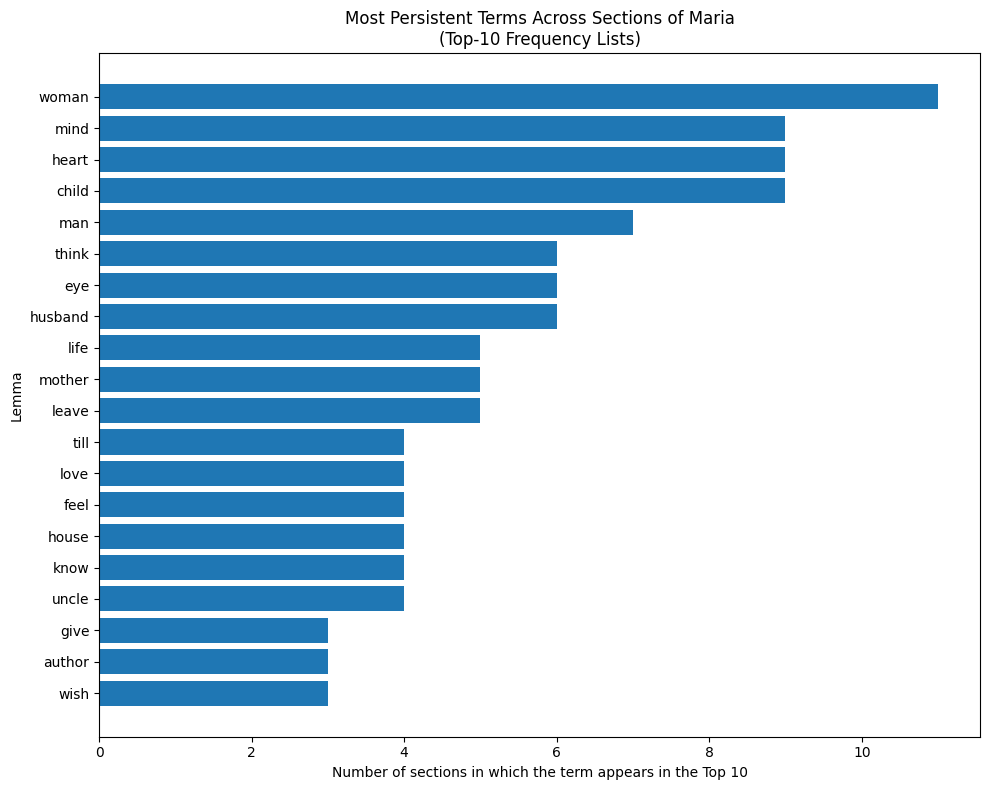

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

top_terms = [
    ('woman', 11),
    ('mind', 9),
    ('heart', 9),
    ('child', 9),
    ('man', 7),
    ('think', 6),
    ('eye', 6),
    ('husband', 6),
    ('life', 5),
    ('mother', 5),
    ('leave', 5),
    ('till', 4),
    ('love', 4),
    ('feel', 4),
    ('house', 4),
    ('know', 4),
    ('uncle', 4),
    ('author', 3),
    ('give', 3),
    ('wish', 3)
]

df = pd.DataFrame(top_terms, columns=["term", "chapters"])

# Sort so largest values appear at the top
df = df.sort_values("chapters", ascending=True)

plt.figure(figsize=(10, 8))

plt.barh(df["term"], df["chapters"])

plt.xlabel("Number of sections in which the term appears in the Top 10")
plt.ylabel("Lemma")
plt.title(
    "Most Persistent Terms Across Sections of Maria\n"
    "(Top-10 Frequency Lists)"
)

plt.tight_layout()
plt.show()

We can add a little flourish by listing the total number of chapters in which the word appears in the list, on the end of each bar.

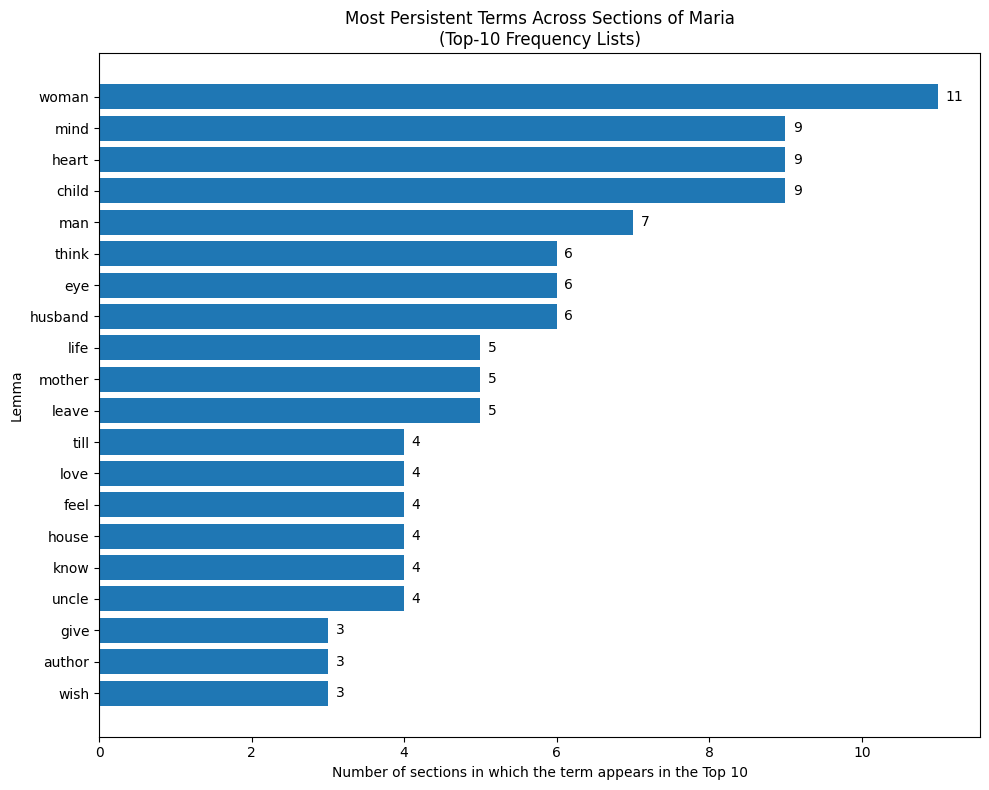

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(top_terms, columns=["term", "chapters"])
df = df.sort_values("chapters", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(df["term"], df["chapters"])

ax.set_xlabel(
    "Number of sections in which the term appears in the Top 10"
)
ax.set_ylabel("Lemma")
ax.set_title(
    "Most Persistent Terms Across Sections of Maria\n"
    "(Top-10 Frequency Lists)"
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.1,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

For the top 10 words in each chapter, a simple table might be nice. 

In [32]:
import pandas as pd

def top_words_table(chapter_top_words, top_n=10):
    """
    Convert chapter top-word lists into a table.

    Parameters
    ----------
    chapter_top_words : dict
        {
            chapter: [
                (word, count),
                ...
            ]
        }

    Returns
    -------
    pandas.DataFrame
    """

    rows = []

    for chapter, words in chapter_top_words.items():

        row = {"Chapter": chapter}

        for rank in range(top_n):

            if rank < len(words):

                word, count = words[rank]

                row[rank + 1] = f"{word} ({count})"

            else:
                row[rank + 1] = ""

        rows.append(row)

    return pd.DataFrame(rows)

In [33]:
top_words_table(maria_top_10_each_chapter)

,Chapter,1,2,3,4,5,6,7,8,9,10
0,MARIA,wrongs (1),woman (1),,,,,,,,
1,PREFACE,author (7),preface (4),public (3),give (3),manner (3),editor (3),present (2),talent (2),wish (2),fragment (2)
2,AUTHOR’S PREFACE,woman (7),wrong (4),mind (3),author (2),like (2),sketch (2),fancy (2),delineation (2),heart (2),novel (2)
3,CHAPTER 1,mind (9),mother (6),life (6),long (6),render (5),time (5),woman (5),endeavour (4),faculty (4),sense (4)
4,CHAPTER 2,heart (13),think (11),mind (10),eye (8),read (7),thought (7),book (7),escape (7),till (7),imagination (6)
5,CHAPTER 3,like (8),woman (7),mind (6),eye (6),country (6),write (5),till (5),life (5),passion (5),man (5)
6,CHAPTER 4,love (7),mind (6),feel (6),emotion (5),give (4),heart (4),imagination (4),long (4),draw (4),happy (4)
7,CHAPTER 5,house (18),mother (15),poor (15),child (14),till (13),say (12),time (12),heart (12),leave (12),mind (12)
8,CHAPTER 6,heart (5),child (5),mother (5),life (4),think (4),eye (4),mind (4),promise (4),hear (3),day (3)
9,CHAPTER 7,mother (17),father (16),child (15),come (13),heart (12),love (12),know (11),brother (11),man (10),country (10)


Based on a simple inspection of this information, I can see some clusters of words. There are words about family, feeling, perception, and marriage. The distinction between family and marriage was pointed out by an LLM as potentially representing a division or sequence in the novel. The distinction between feeling and perception is my own intuition. Based on these insights, I'm going to generate a list of words in each category, and use these lists to plot different graphs.

After that, I'll have an LLM generate a method for plotting the frequency of each word in a list across the list of chapters. Each graph will have multiple words.

In [34]:
family = [
    'mother',
    'father',
    'brother',
    'uncle',
    'child'
]

feeling = [
    'emotion',
    'affection',
    'imagination',
    'heart',
    'like',
    'feel'
]

perception = [
    'mind',
    'eye', 
    'think',
    'see',
    'thought',
    'feel',
    'reason'
]

marriage =[
    'husband',
    'wife',
    'remain',
    'conduct',
    'bed',
    'law',
    'house'
]

In [35]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def plot_lemma_frequencies(lemmas, token_dict):
    """
    Plot absolute lemma frequencies by chapter.

    Parameters
    ----------
    lemmas : list[str]
        List of lemmas to track.

    token_dict : dict
        Dictionary of the form:
        {
            "CHAPTER 1": spacy_doc,
            ...
        }

    Returns
    -------
    pandas.DataFrame
        Frequency table used for plotting.
    """

    rows = []

    for chapter, doc in token_dict.items():

        freqs = Counter(
            token.lemma_.lower()
            for token in doc
            if not token.is_punct
        )

        row = {"chapter": chapter}

        for lemma in lemmas:
            row[lemma] = freqs.get(lemma.lower(), 0)

        rows.append(row)

    df = pd.DataFrame(rows)

    # Plot
    plt.figure(figsize=(12, 6))

    for lemma in lemmas:
        plt.plot(
            df.index,
            df[lemma],
            marker="o",
            label=lemma
        )

    plt.xticks(
        df.index,
        df["chapter"],
        rotation=45,
        ha="right"
    )

    plt.xlabel("Chapter")
    plt.ylabel("Absolute Frequency")
    plt.title("Lemma Frequencies by Chapter")
    plt.legend()

    plt.tight_layout()
    plt.show()

    return df

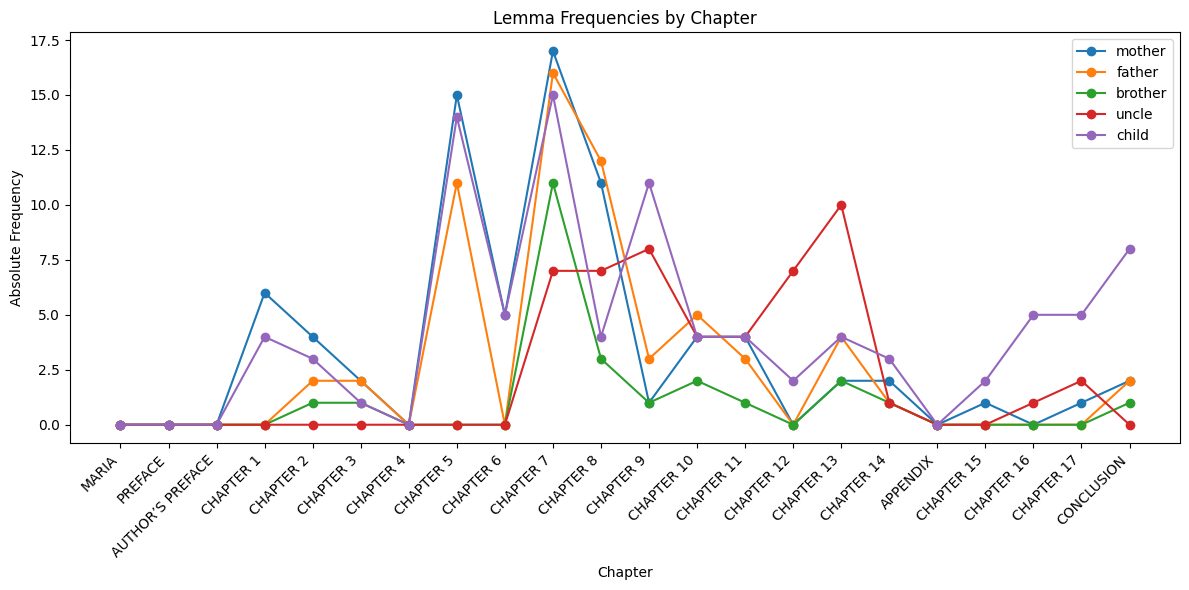

,chapter,mother,father,brother,uncle,child
0,MARIA,0,0,0,0,0
1,PREFACE,0,0,0,0,0
2,AUTHOR’S PREFACE,0,0,0,0,0
3,CHAPTER 1,6,0,0,0,4
4,CHAPTER 2,4,2,1,0,3
5,CHAPTER 3,2,2,1,0,1
6,CHAPTER 4,0,0,0,0,0
7,CHAPTER 5,15,11,0,0,14
8,CHAPTER 6,5,0,0,0,5
9,CHAPTER 7,17,16,11,7,15


In [36]:
plot_lemma_frequencies(family, maria_tokens)

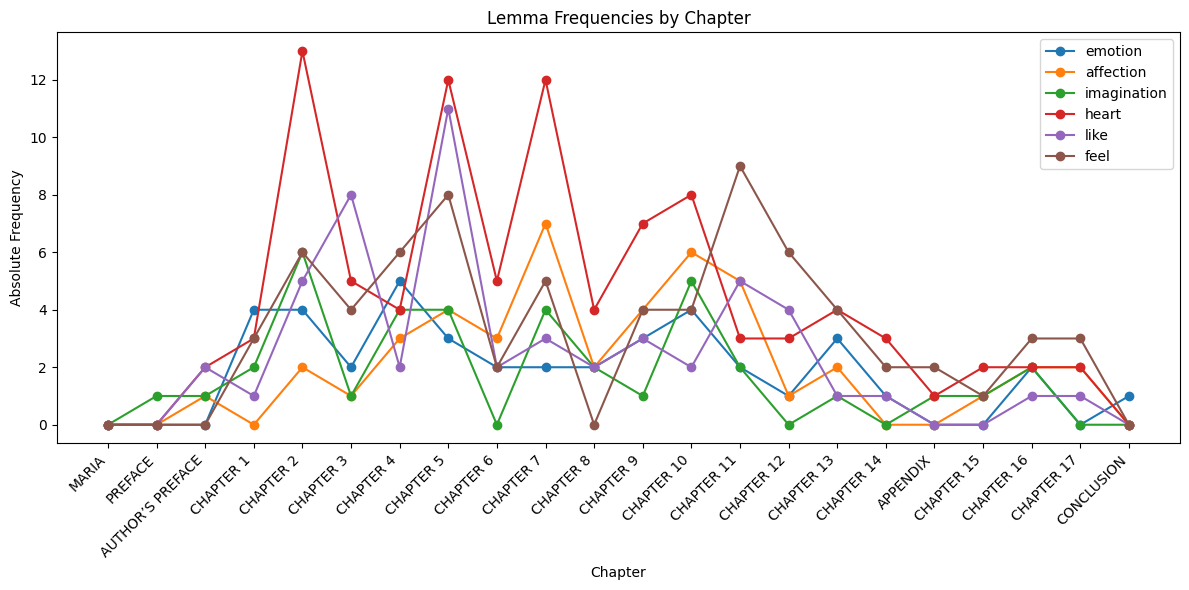

,chapter,emotion,affection,imagination,heart,like,feel
0,MARIA,0,0,0,0,0,0
1,PREFACE,0,0,1,0,0,0
2,AUTHOR’S PREFACE,0,1,1,2,2,0
3,CHAPTER 1,4,0,2,3,1,3
4,CHAPTER 2,4,2,6,13,5,6
5,CHAPTER 3,2,1,1,5,8,4
6,CHAPTER 4,5,3,4,4,2,6
7,CHAPTER 5,3,4,4,12,11,8
8,CHAPTER 6,2,3,0,5,2,2
9,CHAPTER 7,2,7,4,12,3,5


In [37]:
plot_lemma_frequencies(feeling, maria_tokens)

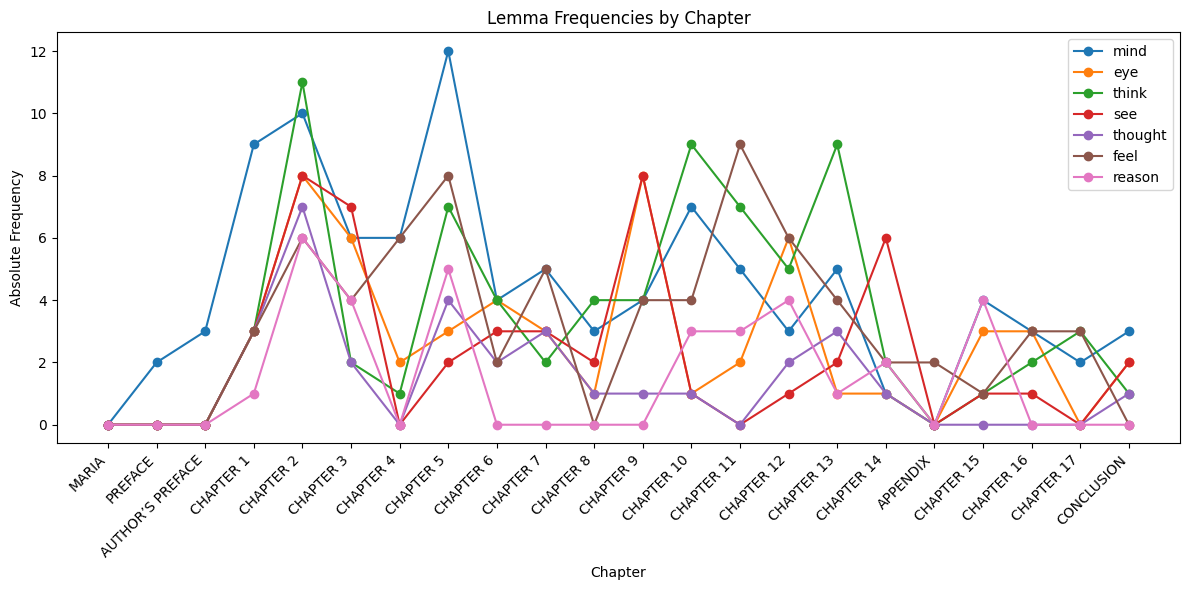

,chapter,mind,eye,think,see,thought,feel,reason
0,MARIA,0,0,0,0,0,0,0
1,PREFACE,2,0,0,0,0,0,0
2,AUTHOR’S PREFACE,3,0,0,0,0,0,0
3,CHAPTER 1,9,3,3,3,3,3,1
4,CHAPTER 2,10,8,11,8,7,6,6
5,CHAPTER 3,6,6,2,7,2,4,4
6,CHAPTER 4,6,2,1,0,0,6,0
7,CHAPTER 5,12,3,7,2,4,8,5
8,CHAPTER 6,4,4,4,3,2,2,0
9,CHAPTER 7,5,3,2,3,3,5,0


In [38]:
plot_lemma_frequencies(perception, maria_tokens)

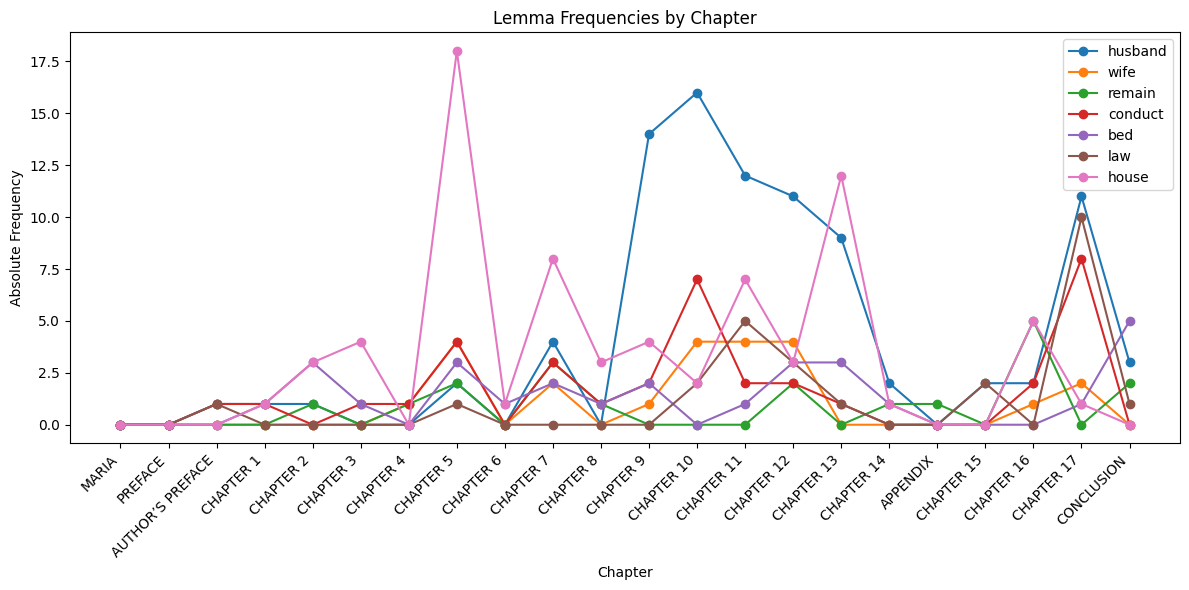

,chapter,husband,wife,remain,conduct,bed,law,house
0,MARIA,0,0,0,0,0,0,0
1,PREFACE,0,0,0,0,0,0,0
2,AUTHOR’S PREFACE,1,0,0,1,0,1,0
3,CHAPTER 1,1,0,0,1,1,0,1
4,CHAPTER 2,1,0,1,0,3,0,3
5,CHAPTER 3,0,0,0,1,1,0,4
6,CHAPTER 4,0,1,1,1,0,0,0
7,CHAPTER 5,2,4,2,4,3,1,18
8,CHAPTER 6,0,0,0,0,1,0,1
9,CHAPTER 7,4,2,3,3,2,0,8


In [39]:
plot_lemma_frequencies(marriage, maria_tokens)

Based on an LLM suggestion, I will then see what it looks like when we clump these lists of words together and plot the resulting frequencies on a series of graphs.

In [40]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def plot_semantic_fields(field_dict, token_dict):
    """
    field_dict example:

    {
        "Perception": ["mind", "think", "see", "eye"],
        "Feeling": ["heart", "love", "feel"],
        "Family": ["mother", "father", "child"],
        "Marriage": ["husband", "law"]
    }
    """

    rows = []

    for chapter, doc in token_dict.items():

        freqs = Counter(
            token.lemma_.lower()
            for token in doc
            if not token.is_punct
        )

        row = {"chapter": chapter}

        for field_name, lemmas in field_dict.items():
            row[field_name] = sum(
                freqs.get(lemma.lower(), 0)
                for lemma in lemmas
            )

        rows.append(row)

    df = pd.DataFrame(rows)

    n_fields = len(field_dict)

    fig, axes = plt.subplots(
        n_fields,
        1,
        figsize=(12, 3 * n_fields),
        sharex=True
    )

    if n_fields == 1:
        axes = [axes]

    for ax, field_name in zip(axes, field_dict):

        ax.plot(
            df.index,
            df[field_name],
            marker="o"
        )

        ax.set_ylabel("Count")
        ax.set_title(field_name)

    axes[-1].set_xticks(df.index)
    axes[-1].set_xticklabels(
        df["chapter"],
        rotation=45,
        ha="right"
    )

    axes[-1].set_xlabel("Chapter")

    plt.tight_layout()
    plt.show()

    return df

In [41]:
maria_word_clusters = {

"family" : [
    'mother',
    'father',
    'brother',
    'uncle',
    'child'
],

"feeling" : [
    'emotion',
    'affection',
    'imagination',
    'heart',
    'like',
    'feel'
],

"perception" : [
    'mind',
    'eye', 
    'think',
    'see',
    'thought',
    'feel',
    'reason'
],

"marriage" :[
    'husband',
    'wife',
    'remain',
    'conduct',
    'bed',
    'law',
    'house'
]
}

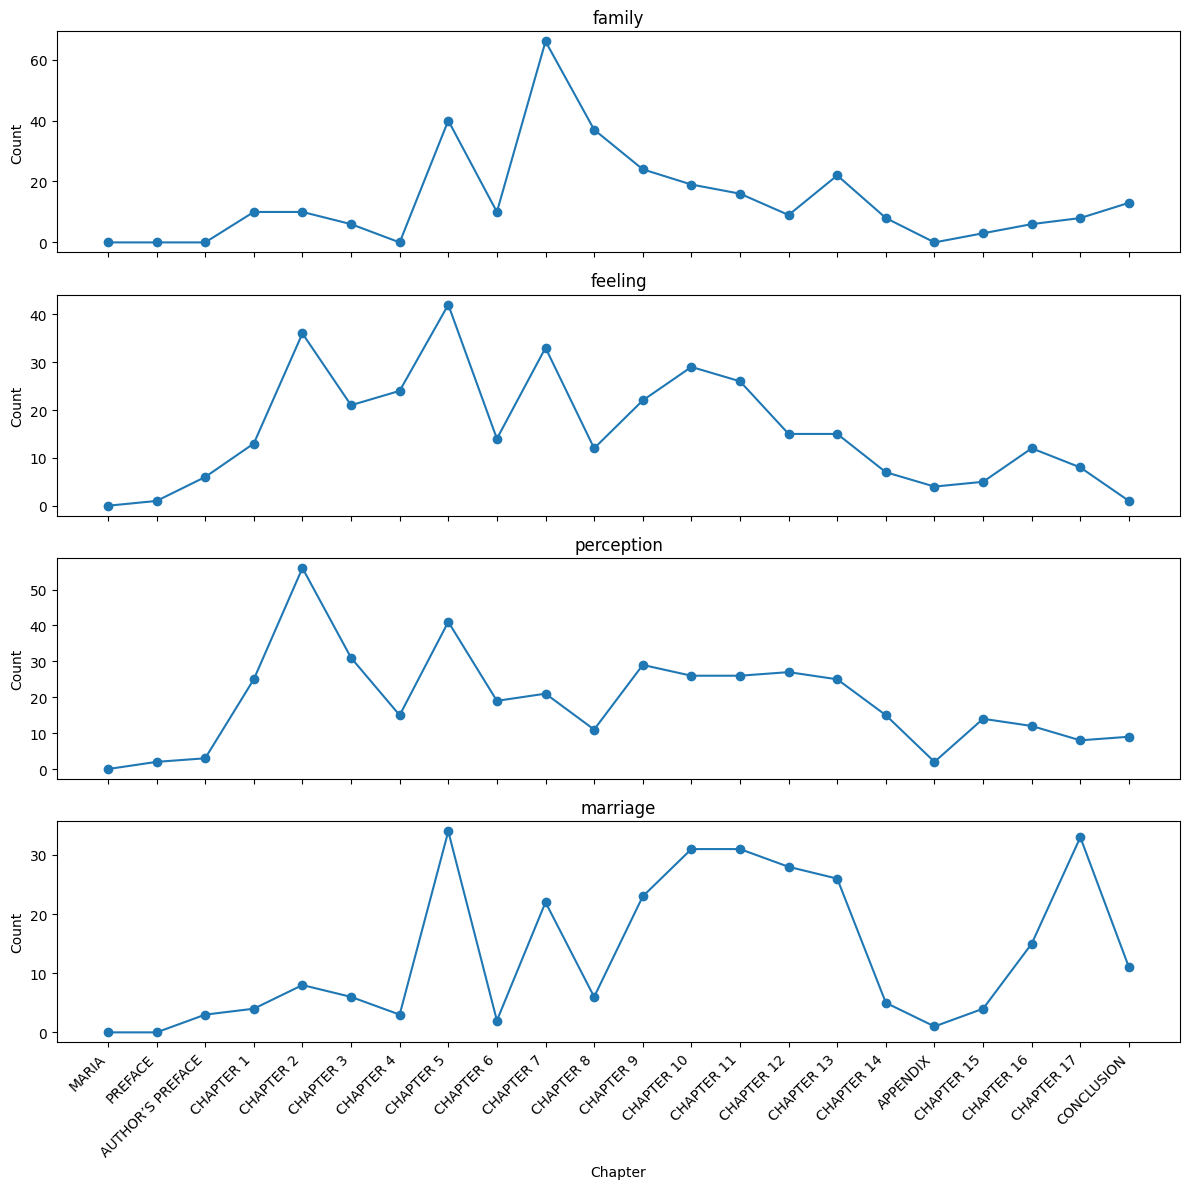

,chapter,family,feeling,perception,marriage
0,MARIA,0,0,0,0
1,PREFACE,0,1,2,0
2,AUTHOR’S PREFACE,0,6,3,3
3,CHAPTER 1,10,13,25,4
4,CHAPTER 2,10,36,56,8
5,CHAPTER 3,6,21,31,6
6,CHAPTER 4,0,24,15,3
7,CHAPTER 5,40,42,41,34
8,CHAPTER 6,10,14,19,2
9,CHAPTER 7,66,33,21,22


In [42]:
plot_semantic_fields(maria_word_clusters, maria_tokens)

Another LLM suggestion is to create a grid of graphs for each word cluster, where each word gets its own individual graph.

In [43]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_word_small_multiples(
    lemmas,
    token_dict,
    relative=False,
    per=1000,
    ncols=4
):
    """
    Plot one frequency trajectory per lemma.

    Parameters
    ----------
    lemmas : list[str]
        Words to track.

    token_dict : dict[str, spacy.Doc]
        Dictionary of tokenized chapters.

    relative : bool
        If True, plot occurrences per 'per' words.
        If False, plot raw counts.

    per : int
        Scaling factor for relative frequencies.

    ncols : int
        Number of subplot columns.

    Returns
    -------
    pandas.DataFrame
        Frequency table used for plotting.
    """

    rows = []

    for chapter, doc in token_dict.items():

        freqs = Counter(
            token.lemma_.lower()
            for token in doc
            if not token.is_punct
        )

        token_count = sum(
            1 for token in doc
            if not token.is_punct
        )

        row = {"chapter": chapter}

        for lemma in lemmas:

            count = freqs.get(lemma.lower(), 0)

            if relative:
                count = count / token_count * per

            row[lemma] = count

        rows.append(row)

    df = pd.DataFrame(rows)

    nwords = len(lemmas)
    nrows = math.ceil(nwords / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 3 * nrows),
        sharex=True
    )

    # Flatten for easier indexing
    axes = axes.flatten()

    for i, lemma in enumerate(lemmas):

        ax = axes[i]

        ax.plot(
            df.index,
            df[lemma],
            marker="o"
        )

        ax.set_title(lemma)

        if relative:
            ax.set_ylabel(f"per {per}")
        else:
            ax.set_ylabel("count")

        ax.grid(True, alpha=0.3)

    # Remove unused panels
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Only label x-axis on bottom row
    for ax in axes:
        ax.set_xticks(df.index)

    chapter_labels = [
        c.replace("CHAPTER ", "")
        if c.startswith("CHAPTER ")
        else c
        for c in df["chapter"]
    ]

    for ax in axes[-ncols:]:
        ax.set_xticklabels(
            chapter_labels,
            rotation=45,
            ha="right"
        )

    fig.suptitle(
        "Lemma Frequency Trajectories by Chapter",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

    return df

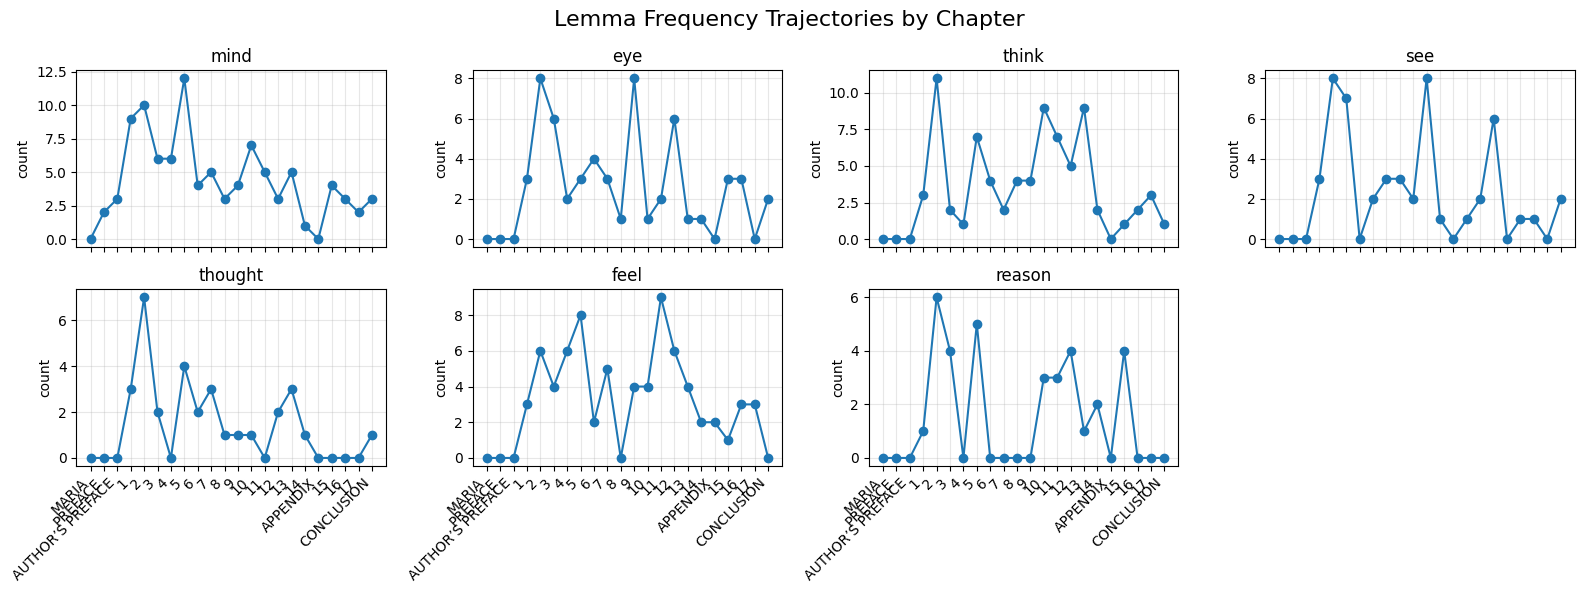

,chapter,mind,eye,think,see,thought,feel,reason
0,MARIA,0,0,0,0,0,0,0
1,PREFACE,2,0,0,0,0,0,0
2,AUTHOR’S PREFACE,3,0,0,0,0,0,0
3,CHAPTER 1,9,3,3,3,3,3,1
4,CHAPTER 2,10,8,11,8,7,6,6
5,CHAPTER 3,6,6,2,7,2,4,4
6,CHAPTER 4,6,2,1,0,0,6,0
7,CHAPTER 5,12,3,7,2,4,8,5
8,CHAPTER 6,4,4,4,3,2,2,0
9,CHAPTER 7,5,3,2,3,3,5,0


In [44]:
plot_word_small_multiples(perception, maria_tokens)

Those are interesting, but what I really want to see is each cluster having its own graph, within which each word has its own line, and see all the graphs nicely stacked on top of one another.

In [45]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_field_lemma_stacks(field_dict, token_dict, relative=False, per=1000, savepath=None):
    """
    Stacked subplots by semantic field, with individual lemma lines.

    Parameters
    ----------
    field_dict : dict
        {
            "Perception": ["mind", "eye", "think"],
            "Feeling": ["heart", "love", "feel"],
            ...
        }

    token_dict : dict
        {
            "CHAPTER 1": spacy_doc,
            ...
        }

    relative : bool
        If True, normalize by chapter length (per `per` tokens)

    per : int
        Scaling factor for relative frequency

    Returns
    -------
    pandas.DataFrame
    """

    rows = []

    for chapter, doc in token_dict.items():

        freqs = Counter(
            token.lemma_.lower()
            for token in doc
            if not token.is_punct
        )

        token_count = sum(
            1 for token in doc
            if not token.is_punct
        )

        row = {"chapter": chapter, "tokens": token_count}

        for field, lemmas in field_dict.items():
            for lemma in lemmas:
                key = f"{field}::{lemma.lower()}"

                val = freqs.get(lemma.lower(), 0)

                if relative:
                    val = val / token_count * per

                row[key] = val

        rows.append(row)

    df = pd.DataFrame(rows)

    n_fields = len(field_dict)

    fig, axes = plt.subplots(
        n_fields,
        1,
        figsize=(14, 4 * n_fields),
        sharex=True
    )

    if n_fields == 1:
        axes = [axes]

    for ax, (field, lemmas) in zip(axes, field_dict.items()):

        for lemma in lemmas:
            col = f"{field}::{lemma.lower()}"

            ax.plot(
                df.index,
                df[col],
                marker="o",
                label=lemma
            )

        ax.set_title(field)
        ax.set_ylabel("Frequency")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xticks(df.index)
    axes[-1].set_xticklabels(
        df["chapter"],
        rotation=45,
        ha="right"
    )

    axes[-1].set_xlabel("Chapter")

    fig.suptitle(
        "Semantic Fields: Lemma Trajectories by Chapter",
        fontsize=14
    )

    plt.tight_layout()
    if savepath:
        fig.savefig(f"{savepath}.png", dpi=300, bbox_inches="tight")
        fig.savefig(f"{savepath}.pdf", bbox_inches="tight")

    plt.show()

    return df

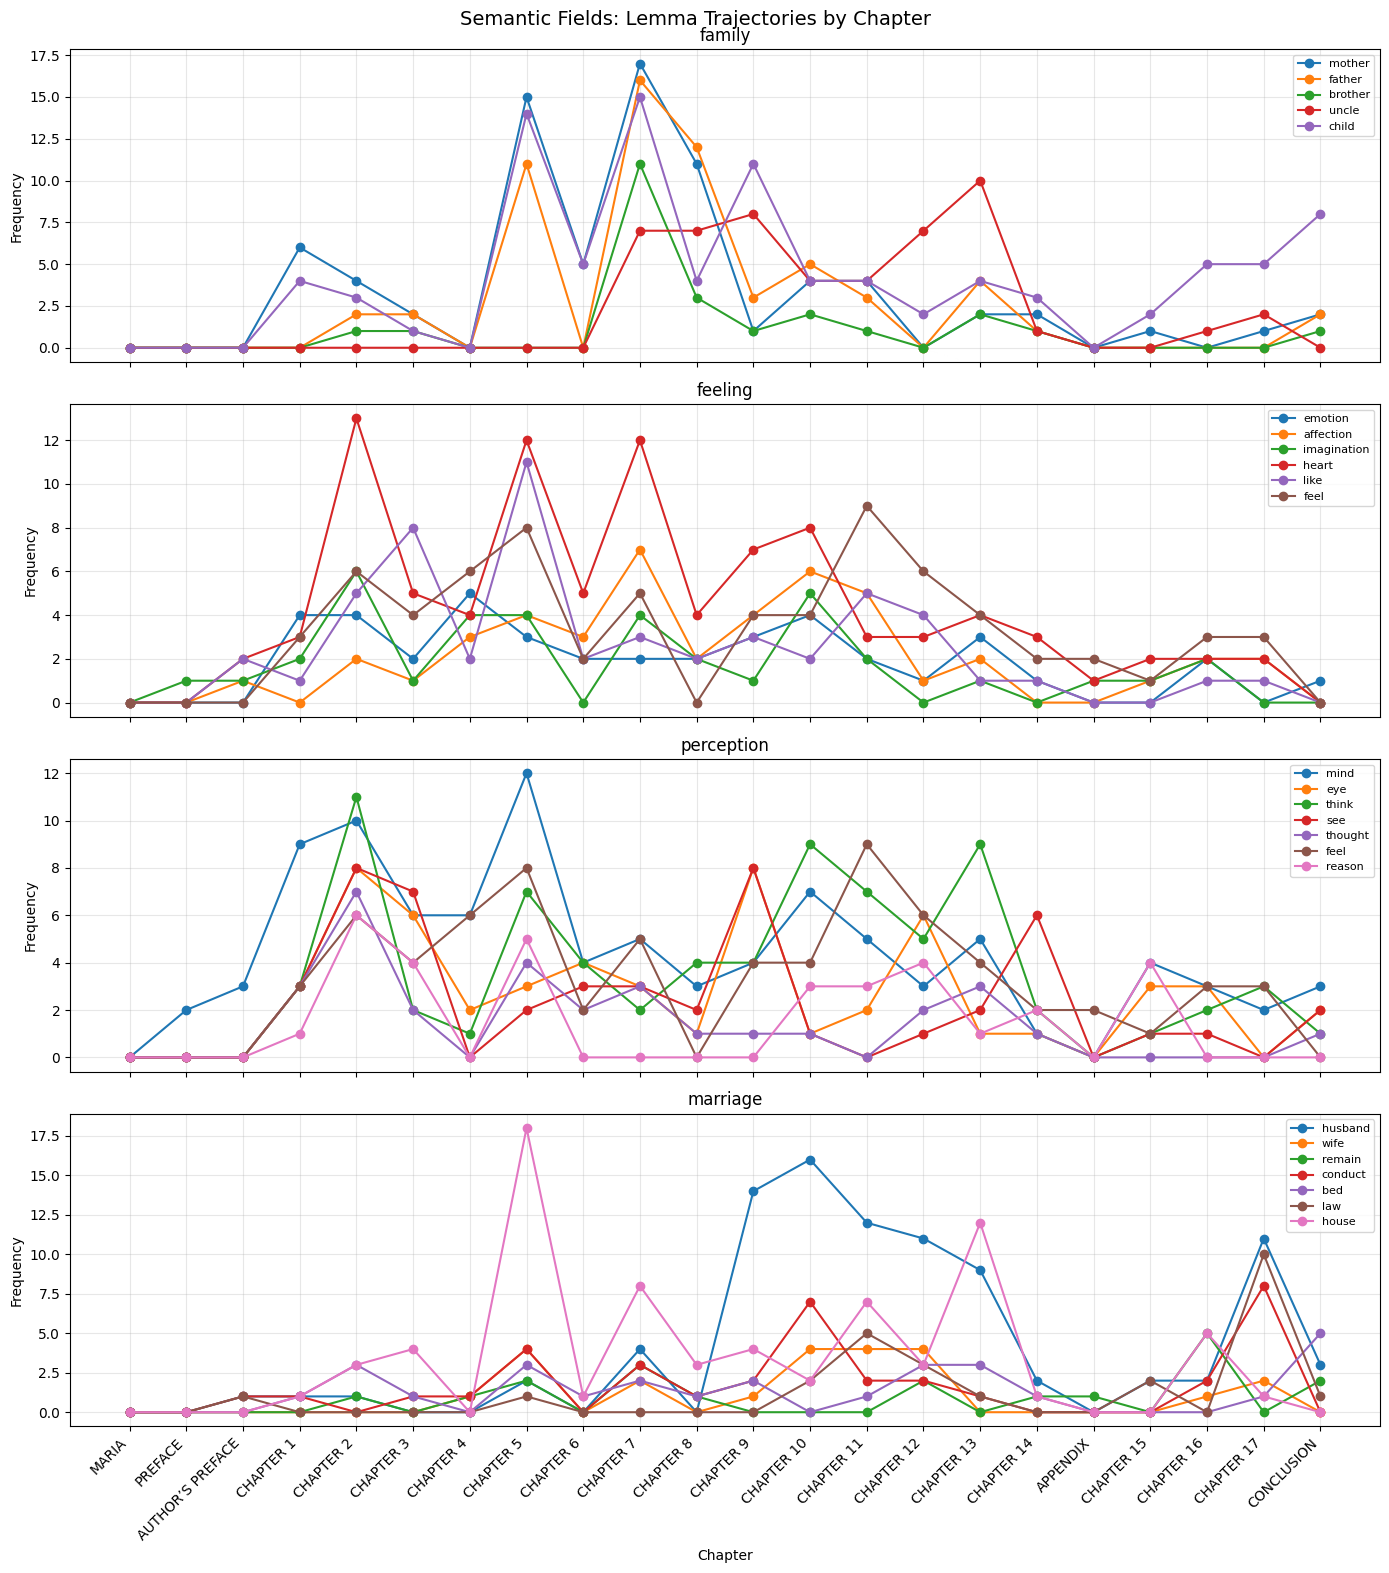

,chapter,tokens,family::mother,family::father,family::brother,family::uncle,family::child,feeling::emotion,feeling::affection,feeling::imagination,...,perception::thought,perception::feel,perception::reason,marriage::husband,marriage::wife,marriage::remain,marriage::conduct,marriage::bed,marriage::law,marriage::house
0,MARIA,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,PREFACE,472,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,AUTHOR’S PREFACE,414,0,0,0,0,0,0,1,1,...,0,0,0,1,0,0,1,0,1,0
3,CHAPTER 1,2197,6,0,0,0,4,4,0,2,...,3,3,1,1,0,0,1,1,0,1
4,CHAPTER 2,3370,4,2,1,0,3,4,2,6,...,7,6,6,1,0,1,0,3,0,3
5,CHAPTER 3,2597,2,2,1,0,1,2,1,1,...,2,4,4,0,0,0,1,1,0,4
6,CHAPTER 4,1325,0,0,0,0,0,5,3,4,...,0,6,0,0,1,1,1,0,0,0
7,CHAPTER 5,6873,15,11,0,0,14,3,4,4,...,4,8,5,2,4,2,4,3,1,18
8,CHAPTER 6,1375,5,0,0,0,5,2,3,0,...,2,2,0,0,0,0,0,1,0,1
9,CHAPTER 7,4247,17,16,11,7,15,2,7,4,...,3,5,0,4,2,3,3,2,0,8


In [46]:
plot_field_lemma_stacks(maria_word_clusters, maria_tokens, savepath='../outputs/maria-word-freqs')

My next thought is to generate word clouds based on raw term frequency for each chapter and arrange the clouds in a grid.

In [47]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import math

def chapter_wordcloud_grid(
    token_dict,
    top_n=15,
    max_cols=4
):
    """
    Generate a grid of small word clouds,
    one for each chapter.
    """

    chapters = list(token_dict.keys())

    n = len(chapters)
    ncols = max_cols
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4*ncols, 3*nrows)
    )

    axes = axes.flatten()

    for ax, chapter in zip(axes, chapters):

        doc = token_dict[chapter]

        freqs = Counter(
            token.lemma_.lower()
            for token in doc
            if (
                not token.is_stop
                and not token.is_punct
                and not token.ent_type_
            )
        )

        top_words = dict(freqs.most_common(top_n))

        wc = WordCloud(
            width=400,
            height=300,
            background_color="white",
            max_words=top_n
        ).generate_from_frequencies(top_words)

        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(chapter, fontsize=10)
        ax.axis("off")

    # remove unused axes
    for ax in axes[len(chapters):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

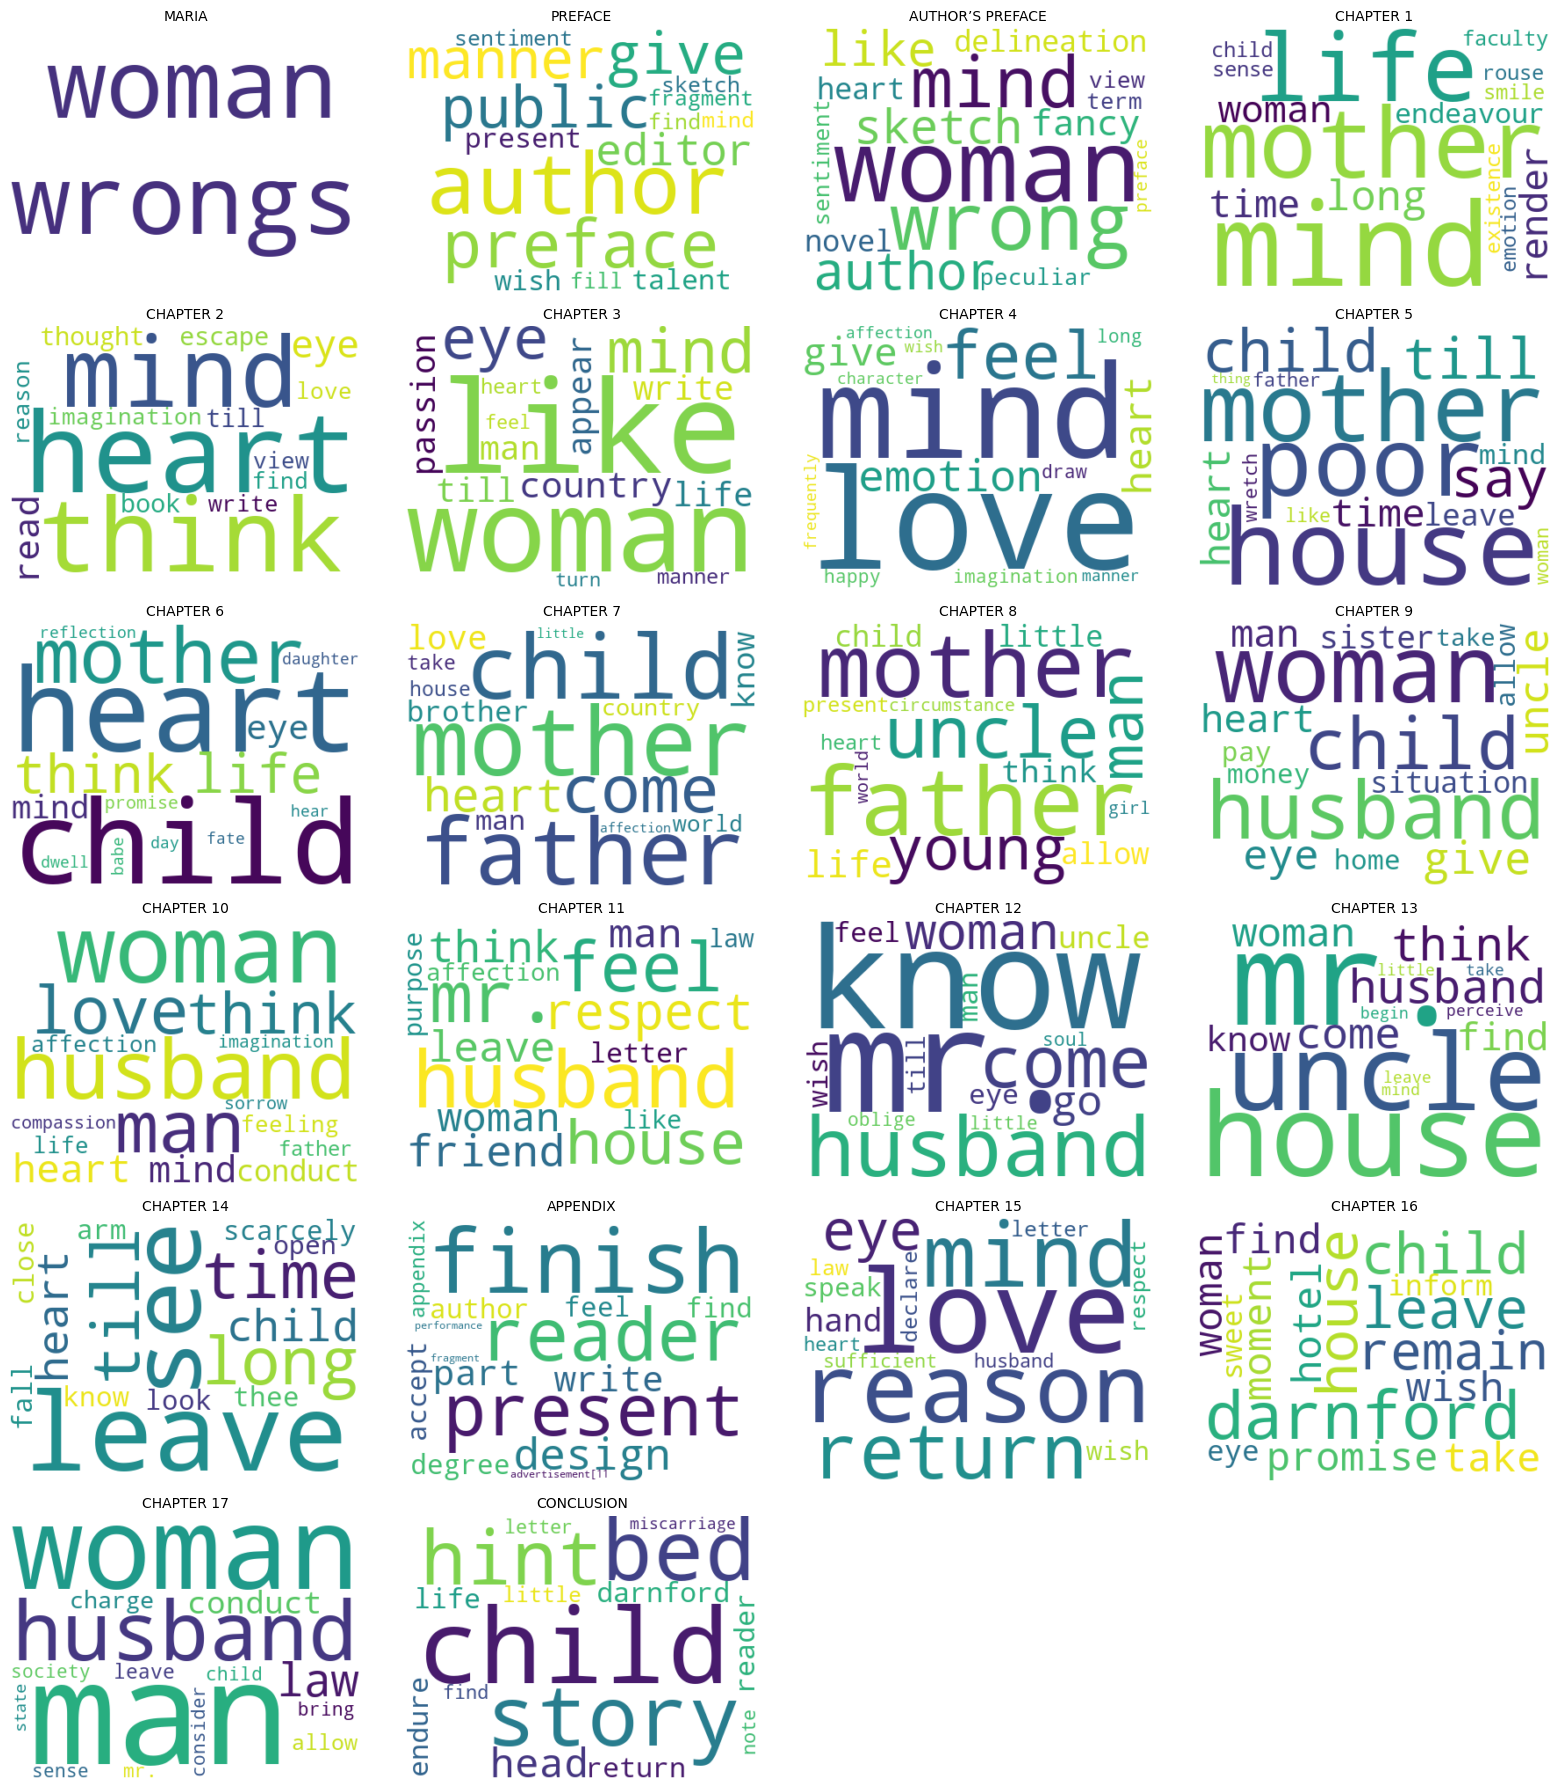

In [48]:
chapter_wordcloud_grid(
    maria_tokens,
    top_n=15,
    max_cols=4
)

Another idea I have is for a stacked bar chart focused on the top ten words that most often appear across all these lists.

In [49]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def plot_top_word_stacked_bars(
    words,
    token_dict,
    relative=False,
    per=1000
):
    """
    Stacked bar chart showing chapter frequencies
    for a selected vocabulary.
    """

    rows = []

    for chapter, doc in token_dict.items():

        freqs = Counter(
            token.lemma_.lower()
            for token in doc
            if not token.is_punct
        )

        token_count = sum(
            1 for token in doc
            if not token.is_punct
        )

        row = {"chapter": chapter}

        for word in words:

            count = freqs.get(word.lower(), 0)

            if relative:
                count = count / token_count * per

            row[word] = count

        rows.append(row)

    df = pd.DataFrame(rows)

    plot_df = df.set_index("chapter")

    ax = plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(14, 8)
    )

    ax.set_xlabel("Chapter")

    if relative:
        ax.set_ylabel(f"Occurrences per {per} tokens")
    else:
        ax.set_ylabel("Frequency")

    ax.set_title(
        f"Distribution of Selected Terms Across Chapters"
    )

    ax.legend(
        title="Lemma",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

    return df

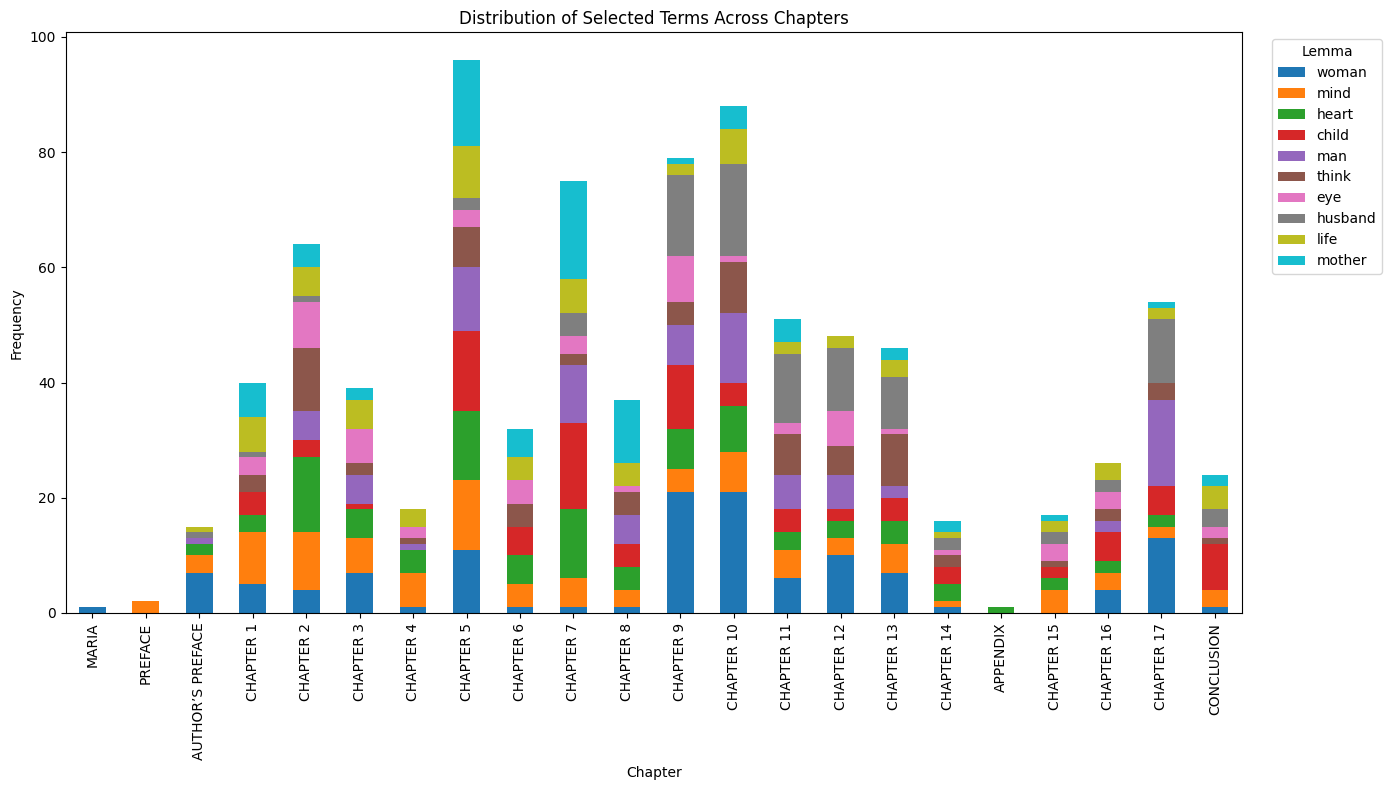

,chapter,woman,mind,heart,child,man,think,eye,husband,life,mother
0,MARIA,1,0,0,0,0,0,0,0,0,0
1,PREFACE,0,2,0,0,0,0,0,0,0,0
2,AUTHOR’S PREFACE,7,3,2,0,1,0,0,1,1,0
3,CHAPTER 1,5,9,3,4,0,3,3,1,6,6
4,CHAPTER 2,4,10,13,3,5,11,8,1,5,4
5,CHAPTER 3,7,6,5,1,5,2,6,0,5,2
6,CHAPTER 4,1,6,4,0,1,1,2,0,3,0
7,CHAPTER 5,11,12,12,14,11,7,3,2,9,15
8,CHAPTER 6,1,4,5,5,0,4,4,0,4,5
9,CHAPTER 7,1,5,12,15,10,2,3,4,6,17


In [50]:
persistent_words = [
    'woman', 'mind', 'heart', 'child',
    'man', 'think', 'eye', 'husband',
    'life', 'mother', 'leave', 'till',
    'love', 'feel', 'house', 'know',
    'uncle', 'author', 'give', 'wish'
]

plot_top_word_stacked_bars(
    persistent_words[:10],
    maria_tokens
)

Next, I'm going to experiment with heat maps. First, I'm going to take that list of the top 20 words that most often appear in lists of the most common words in a chapter, and I'm going to create a heat map for them with raw frequencies.

In [51]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def plot_word_heatmap(
    words,
    token_dict,
    relative=False,
    per=1000,
    figsize=(14, 8)
):
    """
    Heatmap of word frequencies by chapter.

    Rows = words
    Columns = chapters
    """

    rows = []

    for chapter, doc in token_dict.items():

        freqs = Counter(
            token.lemma_.lower()
            for token in doc
            if not token.is_punct
        )

        token_count = sum(
            1 for token in doc
            if not token.is_punct
        )

        chapter_data = {}

        for word in words:

            value = freqs.get(word.lower(), 0)

            if relative:
                value = value / token_count * per

            chapter_data[word] = value

        rows.append(chapter_data)

    df = pd.DataFrame(
        rows,
        index=list(token_dict.keys())
    )

    heatmap_data = df.T

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        heatmap_data,
        aspect='auto',
        interpolation='nearest'
    )

    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(
        heatmap_data.columns,
        rotation=45,
        ha='right'
    )

    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    ax.set_xlabel("Chapter")
    ax.set_ylabel("Lemma")

    if relative:
        title = f"Relative Frequencies (per {per} words)"
    else:
        title = "Absolute Frequencies"

    ax.set_title(title)

    cbar = plt.colorbar(im)
    cbar.set_label("Frequency")

    plt.tight_layout()
    plt.show()

    return heatmap_data

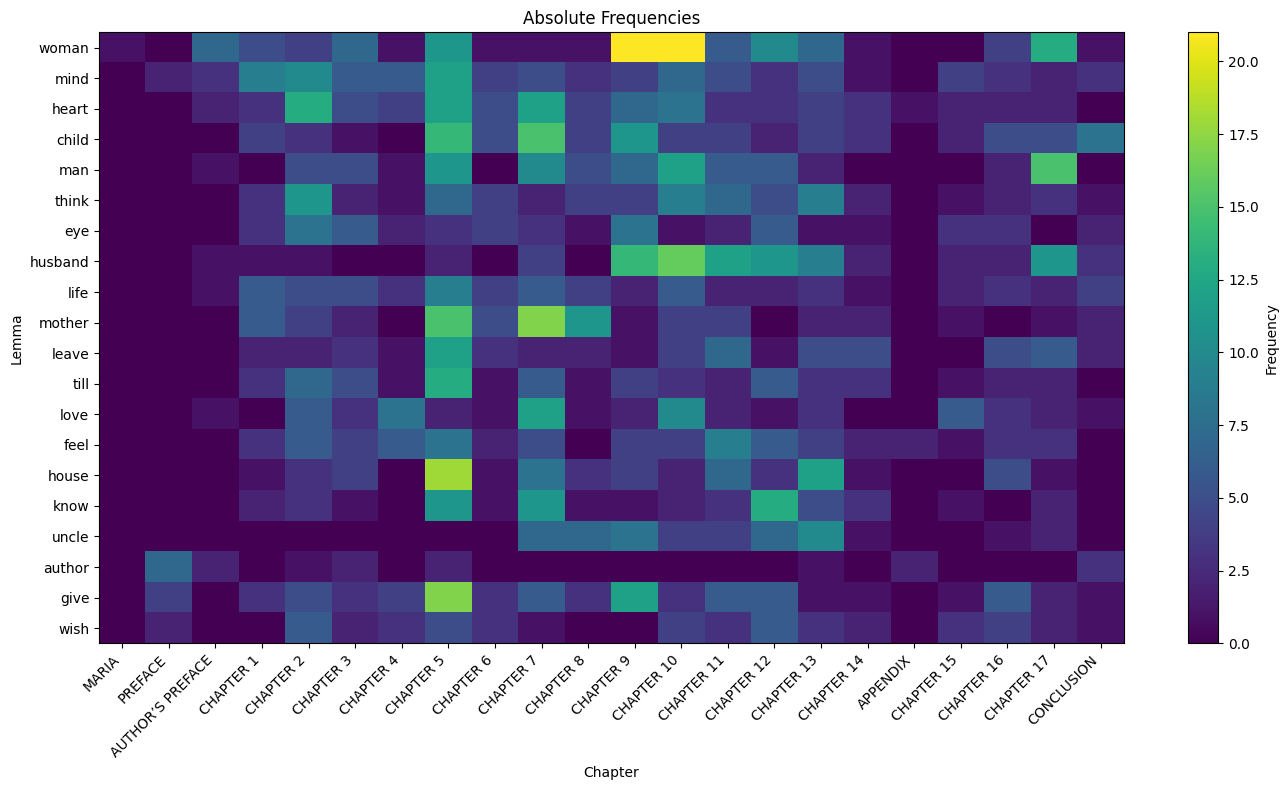

In [52]:
heatmap_df = plot_word_heatmap(
    persistent_words,
    maria_tokens
)

The result is honestly, for me, not all that evocative. So I'm going to expand it to a lot more words: all the words that ever appear in a list of the top ten most common words in any chapter.

In addition, I'm going to accept an LLM suggestion to normalize the frequencies and organize the rows in a sequence by what words are have the highest normalized frequency for that chapter. Let's talk about what this means.

Let's say woman appears 21 times in chapter 10, and 7 times in the preface. 21 times is the highest number of times woman appears in any chapter, so it gets the score of 1.0. For the preface, woman gets a score of 7/21, or 0.33. This means that the heat map will show where each word gets its maximum number of appearances, as well as showing where those words also get appearances.

In [53]:
from collections import Counter

def chapter_top_words(
    token_dict,
    top_n=10,
    remove_stopwords=True,
    remove_punct=True,
    remove_entities=True,
    lowercase=True
):
    """
    Generate top-N word lists for each chapter.

    Parameters
    ----------
    token_dict : dict[str, spacy.Doc]

    top_n : int
        Number of most frequent words to return.

    Returns
    -------
    dict
        {
            chapter: [
                (word, frequency),
                ...
            ]
        }
    """

    results = {}

    for chapter, doc in token_dict.items():

        freqs = Counter()

        for token in doc:

            if remove_stopwords and token.is_stop:
                continue

            if remove_punct and token.is_punct:
                continue

            if remove_entities and token.ent_type_:
                continue

            lemma = token.lemma_

            if lowercase:
                lemma = lemma.lower()

            freqs[lemma] += 1

        results[chapter] = freqs.most_common(top_n)

    return results

In [54]:
maria_top10 = chapter_top_words(maria_tokens)

In [55]:
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

def plot_top10_heatmap(
    chapter_top_words,
    normalize_rows=False,
    figsize=(14, 12)
):
    """
    Heatmap using all words appearing in
    any chapter's top-10 list.
    """

    chapters = list(chapter_top_words.keys())

    vocab = sorted({
        word
        for chapter in chapter_top_words
        for word, _ in chapter_top_words[chapter]
    })

    df = pd.DataFrame(
        0,
        index=vocab,
        columns=chapters,
        dtype=float
    )

    for chapter, words in chapter_top_words.items():

        for word, freq in words:
            df.loc[word, chapter] = freq

    # Sort rows by peak chapter
    peak_cols = df.values.argmax(axis=1)

    df["_peak"] = peak_cols

    df = (
        df
        .sort_values("_peak")
        .drop(columns="_peak")
    )

    if normalize_rows:

        row_max = df.max(axis=1)

        df = df.div(
            row_max.where(row_max > 0, 1),
            axis=0
        )

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        df,
        aspect="auto",
        interpolation="nearest"
    )

    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(
        df.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)

    title = (
        "Top-10 Vocabulary Heatmap"
        if not normalize_rows
        else
        "Top-10 Vocabulary Heatmap (Row Normalized)"
    )

    ax.set_title(title)

    plt.colorbar(
        im,
        label="Frequency"
    )

    plt.tight_layout()
    plt.show()

    return df

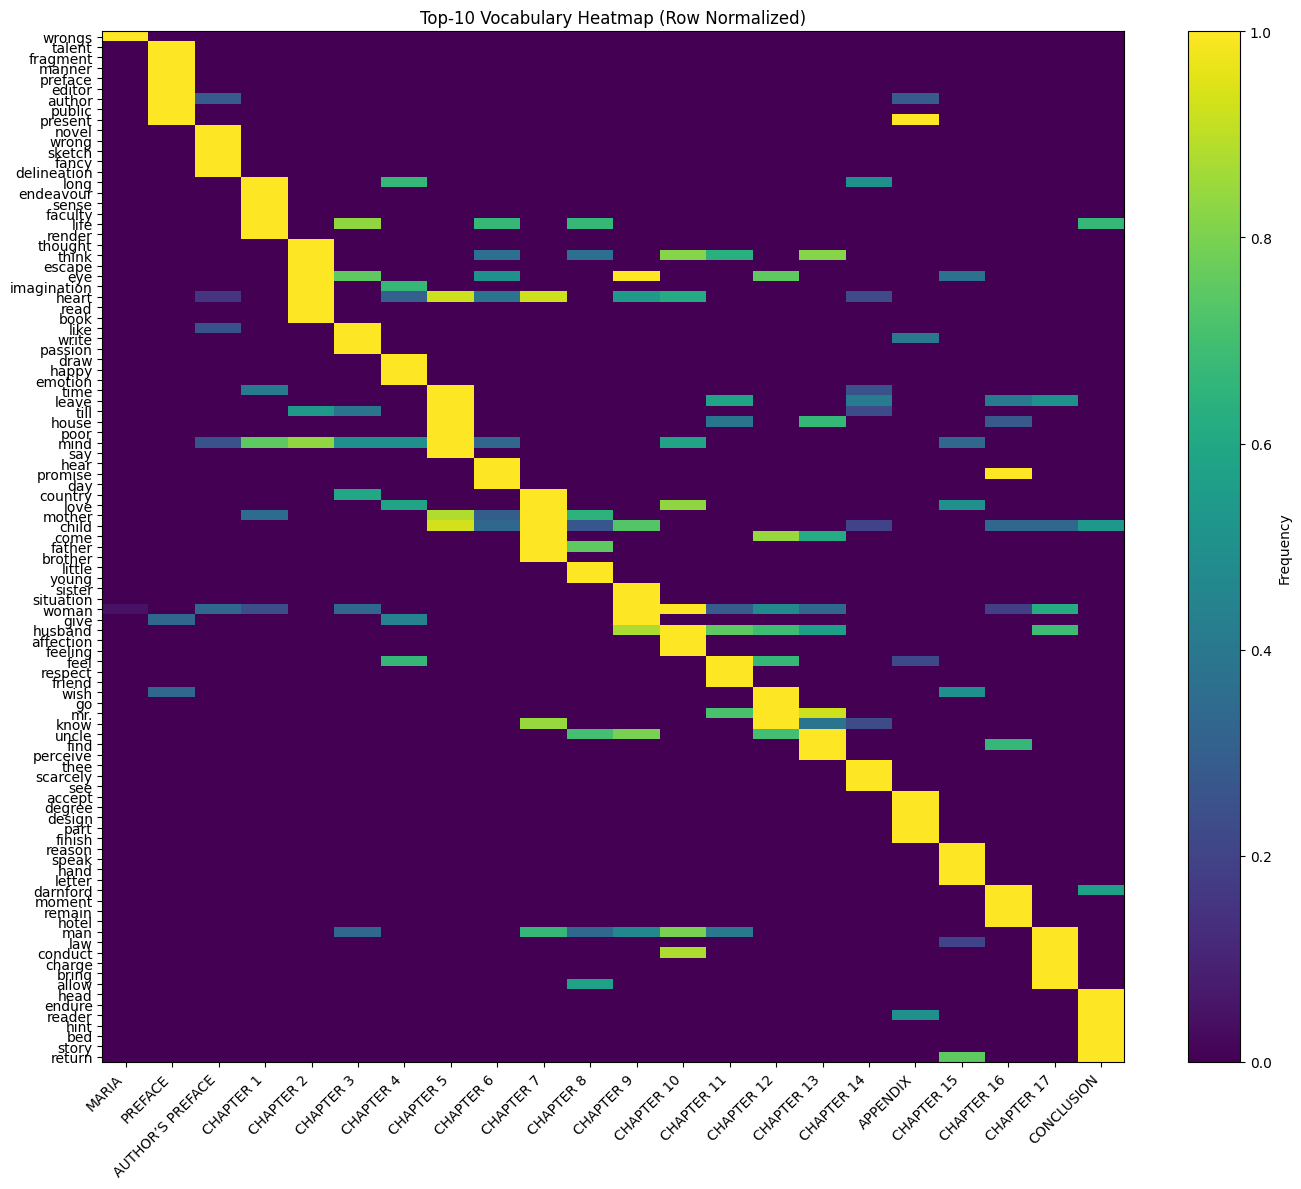

,MARIA,PREFACE,AUTHOR’S PREFACE,CHAPTER 1,CHAPTER 2,CHAPTER 3,CHAPTER 4,CHAPTER 5,CHAPTER 6,CHAPTER 7,...,CHAPTER 10,CHAPTER 11,CHAPTER 12,CHAPTER 13,CHAPTER 14,APPENDIX,CHAPTER 15,CHAPTER 16,CHAPTER 17,CONCLUSION
wrongs,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
talent,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
fragment,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
manner,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
preface,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reader,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.5,0.00,0.0,0.0,1.0
hint,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1.0
bed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1.0
story,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1.0


In [56]:
plot_top10_heatmap(
    maria_top10,
    normalize_rows=True
)

All that was fun, but I also want to visualize TF-IDF. I'll to start with a simple table, just as we did for the word frequencies. The raw TF-IDF scores have a lot of decimals, so I'm going to filter them down to just three decimal places for visualization. I develop a method to format the scores. I'll use it to generate a new version of the TF-IDF data, while keeping the original unchanged. Then I'll run the `top_words_table` method on the formatted data.

In [57]:
def format_tfidf_scores(tfidf_dict, decimals=3):
    """
    Round TF-IDF scores for display purposes.

    Parameters
    ----------
    tfidf_dict : dict
        {
            chapter: [
                (word, score),
                ...
            ]
        }

    decimals : int
        Number of decimal places to keep.

    Returns
    -------
    dict
        Same structure with rounded scores.
    """

    return {
        chapter: [
            (word, round(score, decimals))
            for word, score in words
        ]
        for chapter, words in tfidf_dict.items()
    }

maria_tfidf_formatted = format_tfidf_scores(maria_tfidf)

top_words_table(maria_tfidf)

,Chapter,1,2,3,4,5,6,7,8,9,10
0,MARIA,wrongs (0.9493173527335843),woman (0.31431920685650033),être (0.0),faith (0.0),fainted (0.0),faintness (0.0),fair (0.0),fairy (0.0),faithful (0.0),fail (0.0)
1,PREFACE,author (0.3463639316373206),preface (0.25794282116229145),public (0.19345711587171857),conception (0.17575394192406668),revise (0.17575394192406668),editor (0.16768851032734344),writer (0.14036432313628597),communicate (0.14036432313628597),fragment (0.14036432313628597),page (0.12897141058114572)
2,AUTHOR’S PREFACE,wrong (0.33482522628698436),woman (0.24292043985182799),delineation (0.2096218328870439),novel (0.1849310221523671),sketch (0.12520339339994047),peculiar (0.12520339339994047),author (0.11803099167413858),heroine (0.10481091644352195),distempered (0.10481091644352195),humanize (0.10481091644352195)
3,CHAPTER 1,faculty (0.11755011581829433),mind (0.11422891963514636),eat (0.10189236886715174),render (0.09601268551480495),court (0.09595058141419799),rouse (0.09567848097927176),mother (0.09513428010941932),life (0.09281800617654228),existence (0.09019744341740836),long (0.0869127237666242)
4,CHAPTER 2,window (0.1298928428913404),heart (0.12698383795755477),book (0.1233454750765395),wretch (0.12051764990788434),read (0.11627950606176321),think (0.11228339446395681),escape (0.10424099042657611),mind (0.09349846081504842),thought (0.08977334140130241),reason (0.08934942036563666)
5,CHAPTER 3,travel (0.1272544133000596),country (0.11520654111261291),theater (0.10818345827726693),like (0.1043486916375567),woman (0.09551885173849897),weary (0.08639975712289757),advantage (0.08639975712289757),street (0.08639975712289757),passion (0.08226314411981997),town (0.08121928069127081)
6,CHAPTER 4,love (0.14219802681510688),happy (0.1355221916769209),draw (0.12093863225292119),feel (0.11653441094853487),reluctant (0.1073928863941934),tint (0.1073928863941934),mind (0.10210702787862816),emotion (0.10157001915364779),rapturous (0.09474335749880149),playful (0.09474335749880149)
7,CHAPTER 5,poor (0.1469824459253137),wretch (0.1421836709655527),house (0.13091197088848572),street (0.11118759012723631),mother (0.103351555964594),mistress (0.09962404052570582),thing (0.09662783456430599),labour (0.09354848623594862),wash (0.09211687058757118),father (0.09178913402629948)
8,CHAPTER 6,dwell (0.1222932630958272),mother (0.10996994266246296),promise (0.10137913675406982),child (0.10046628027521935),night (0.09801581487782413),you (0.09801581487782413),assurance (0.09801581487782413),prepare (0.0938369103393042),fate (0.0938369103393042),heart (0.09196496457913671)
9,CHAPTER 7,father (0.19819128083335402),mother (0.16364838254574116),brother (0.13500171407615988),child (0.13191688246303349),country (0.12946071061831066),eld (0.12869930782085126),come (0.12514288077027266),love (0.11957628803523294),spring (0.10705114836964368),know (0.1058901298825384)


Next, I'm going to do a TF-IDF heatmap. This will show the most distinctive words for each chapter, as well as showing what other chapters that word is distinctive in. First, I'm going to filter out the novel title, the preface, and the appendix. Then we'll generate the heatmap.

In [58]:
filtered_chapter_tf_idf = {
    chapter: words
    for chapter, words in maria_tfidf.items()
    if chapter.startswith("CHAPTER")
       or chapter == "CONCLUSION"
       or chapter == "AUTHOR’S PREFACE"
}

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_tfidf_heatmap(
    tfidf_dict,
    normalize_rows=False,
    figsize=(14, 20)
):
    """
    Plot a heatmap of TF-IDF scores.

    Parameters
    ----------
    tfidf_dict : dict
        {
            chapter: [
                (word, tfidf_score),
                ...
            ]
        }

    normalize_rows : bool
        If True, scale each word by its maximum TF-IDF score.
    """

    chapters = list(tfidf_dict.keys())

    vocab = sorted({
        word
        for words in tfidf_dict.values()
        for word, _ in words
    })

    df = pd.DataFrame(
        0.0,
        index=vocab,
        columns=chapters
    )

    for chapter, words in tfidf_dict.items():

        for word, score in words:
            df.loc[word, chapter] = score

    # Sort rows by peak chapter
    peak_cols = df.values.argmax(axis=1)

    df["_peak"] = peak_cols

    df = (
        df
        .sort_values("_peak")
        .drop(columns="_peak")
    )

    if normalize_rows:

        row_max = df.max(axis=1)

        df = df.div(
            row_max.where(row_max > 0, 1),
            axis=0
        )

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        df,
        aspect="auto",
        interpolation="nearest",
        cmap="plasma"
    )

    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(
        df.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)

    title = (
        "TF-IDF Heatmap"
        if not normalize_rows
        else
        "TF-IDF Heatmap (Row Normalized)"
    )

    ax.set_title(title)

    cbar = plt.colorbar(im)
    cbar.set_label("TF-IDF Score")

    plt.tight_layout()
    plt.show()

    return df

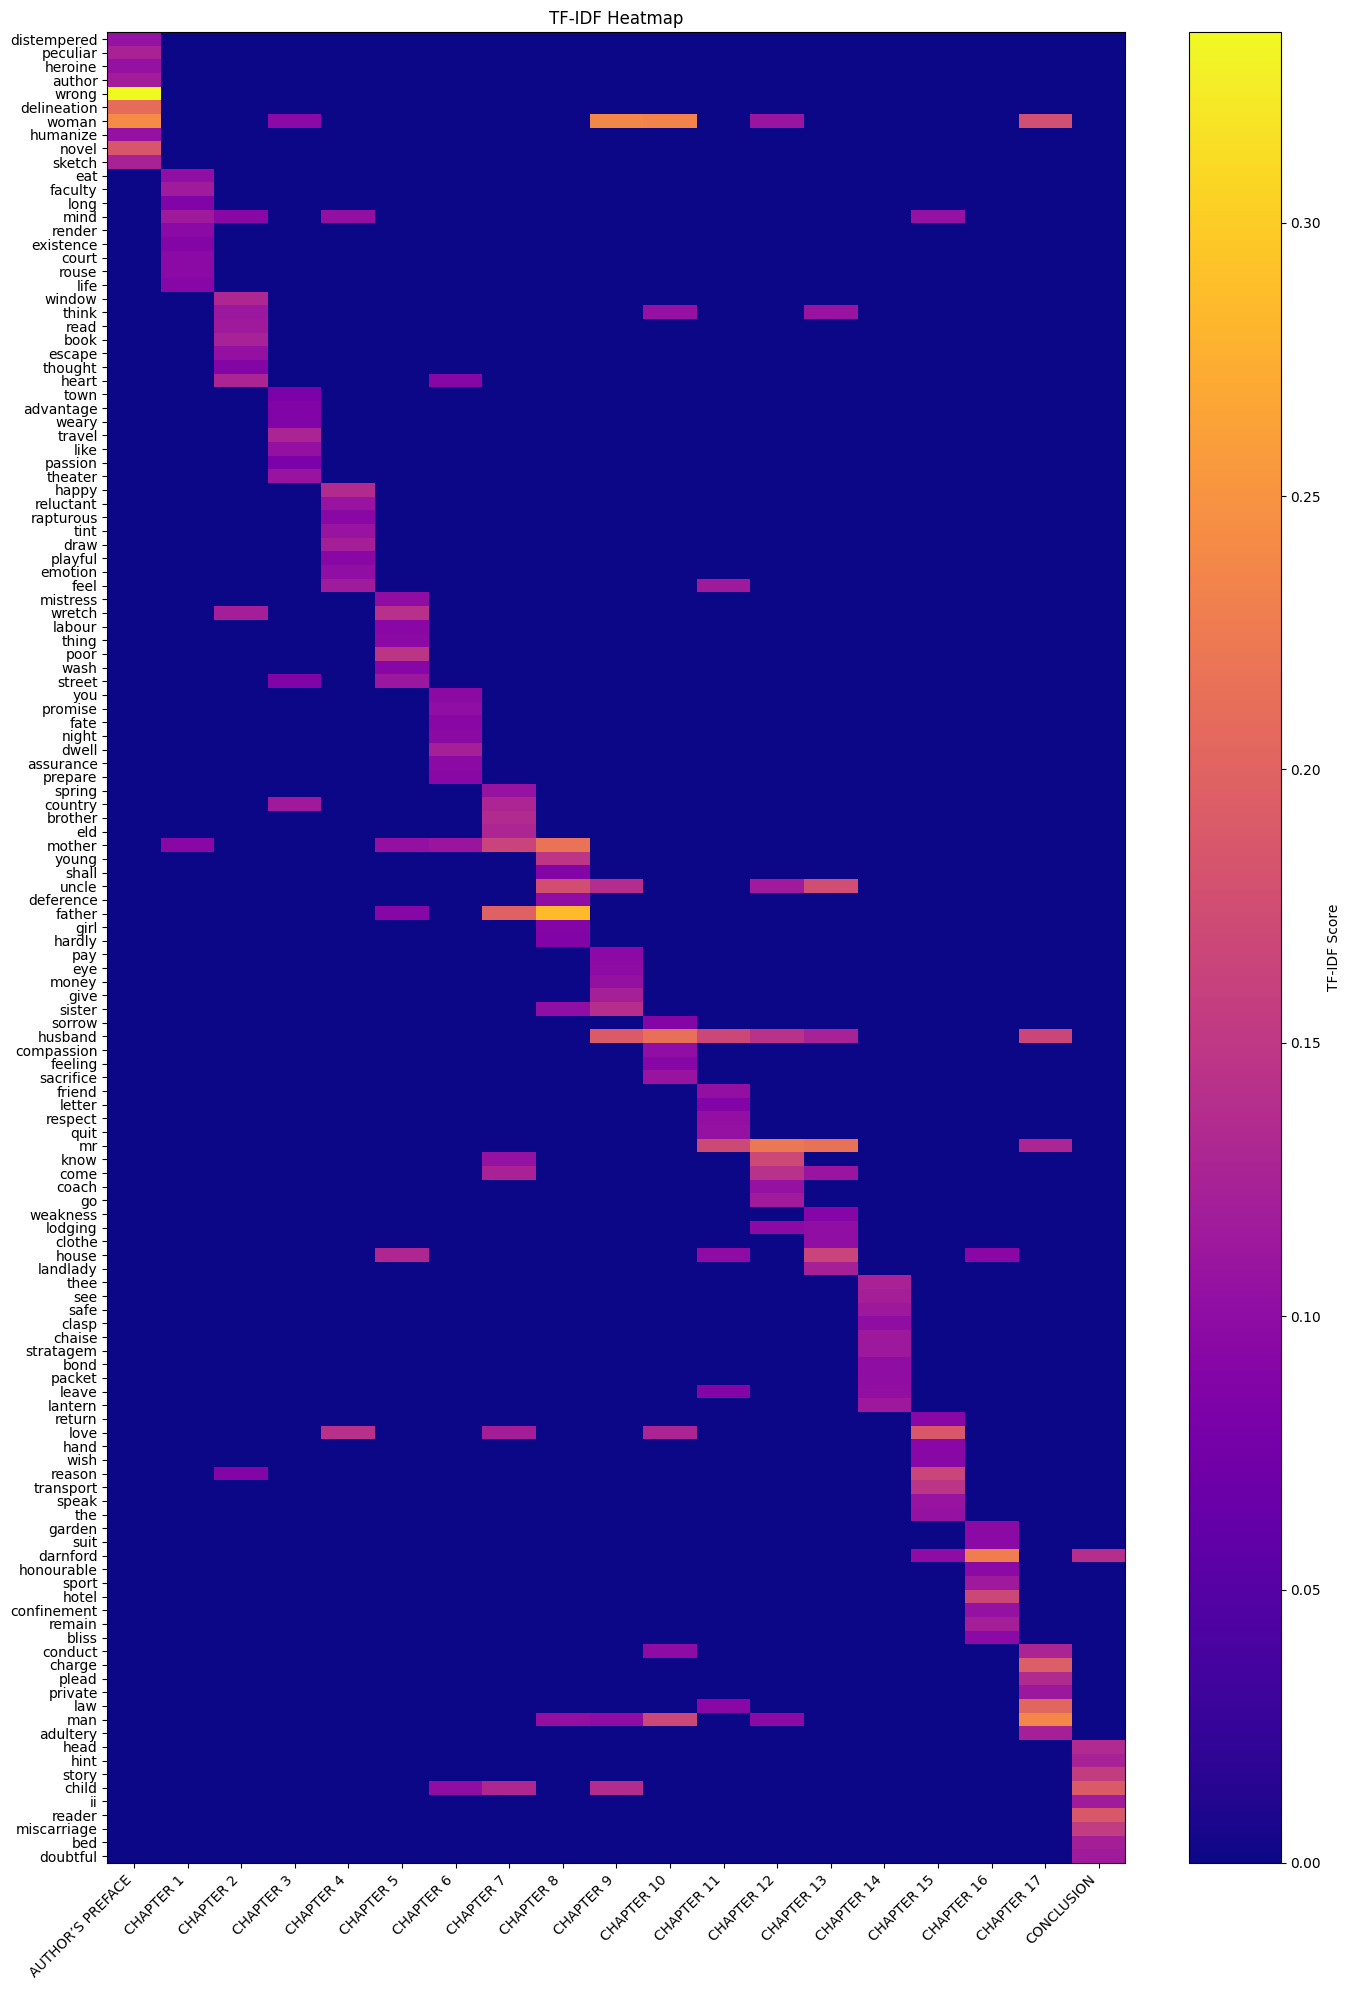

,AUTHOR’S PREFACE,CHAPTER 1,CHAPTER 2,CHAPTER 3,CHAPTER 4,CHAPTER 5,CHAPTER 6,CHAPTER 7,CHAPTER 8,CHAPTER 9,CHAPTER 10,CHAPTER 11,CHAPTER 12,CHAPTER 13,CHAPTER 14,CHAPTER 15,CHAPTER 16,CHAPTER 17,CONCLUSION
distempered,0.104811,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
peculiar,0.125203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
heroine,0.104811,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
author,0.118031,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
wrong,0.334825,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ii,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.117112
reader,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.187061
miscarriage,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.154977
bed,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.121408


In [60]:
plot_tfidf_heatmap(
    filtered_chapter_tf_idf,
    normalize_rows=False
)

## KDE Density Estmimation

Now I'm going to explore a different way of visualizing word frequency. David McClure pioneered the use of kernel density estimation as a way of visualizing the frequency distribution of words across a novel. Instead of looking at the novel chapter by chapter, this will divide the novel into an arbitrary number of equal portions. Based on the distribution of words across the novel, it will generate estimates of the probability of finding the word in any given portion. Based on a bandwidth variable, it will smooth the curve, more with higher bandwidth numbers (evening out the peaks and troughs), less with lower bandwidths.

First, I'll tokenize the novel, then I'll generate a version with no punctuation.

In [61]:
maria_doc = nlp(maria)

In [62]:
maria_no_punct = [
    token
    for token in maria_doc
    if not token.is_punct
]

Now Ill generate a method that accepts a list of lemmas and a tokenized document. It looks through the document, finds those lemmas, and calculates the kernel density curve for those lemmas, then plots them on a graph. It allows for altering the bandwidth and the number of points.

In [63]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt


def plot_lemma_kde(
    lemmas,
    doc,
    bandwidth=None,
    points=1000
):
    """
    Plot KDE trajectories of lemmas across a text.

    Parameters
    ----------
    lemmas : list[str]
        Lemmas to plot.

    doc : spacy.Doc
        Entire text as one tokenized document.

    bandwidth : float or None
        KDE bandwidth adjustment.

    points : int
        Number of x-axis points.
    """

    total_tokens = len(doc)

    x_grid = np.linspace(0, 1000, points)

    plt.figure(figsize=(12, 6))

    for lemma in lemmas:

        positions = []

        for i, token in enumerate(doc):

            if token.lemma_.lower() == lemma.lower():

                position = (i / total_tokens) * 1000

                positions.append(position)

        if len(positions) < 2:
            print(f"Skipping '{lemma}' (too few occurrences)")
            continue

        kde = gaussian_kde(
            positions,
            bw_method=bandwidth
        )

        plt.plot(
            x_grid,
            kde(x_grid),
            label=lemma
        )

    plt.xlabel("Word Offset (0–1000)")
    plt.ylabel("Density")
    plt.title("Lemma Distribution Across Text")
    plt.legend()

    plt.tight_layout()
    plt.show()

Here I take six lemmas that have come up in the frequency distributions as important words, and plot their kde curves.

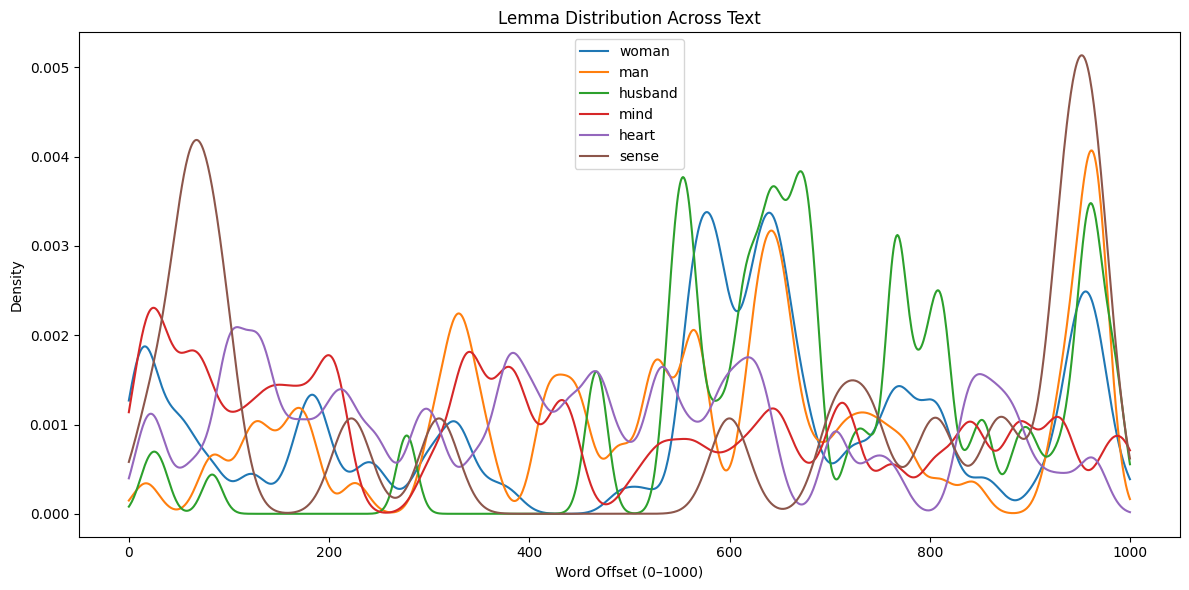

In [64]:
plot_lemma_kde(
    ['woman', 'man', 'husband', 'mind', 'heart', 'sense'],
    maria_doc,
    0.05
)

Next is a method to derive the kde numbers for any single word, but I ended up not using this.

In [65]:
from scipy.stats import gaussian_kde
import numpy as np

def word_kde(lemma, doc, points=1000):

    positions = []

    content_tokens = [
        t for t in doc
        if not t.is_punct
    ]

    total = len(content_tokens)

    for i, token in enumerate(content_tokens):

        if token.lemma_.lower() == lemma.lower():

            positions.append(
                i / total * 1000
            )

    if len(positions) < 2:
        return None

    kde = gaussian_kde(positions)

    x = np.linspace(0, 1000, points)

    y = kde(x)

    # Normalize area to 1
    y = y / np.trapezoid(y, x)

    return x, y

In [66]:
word_kde('woman', maria_no_punct)

(array([   0.        ,    1.001001  ,    2.002002  ,    3.003003  ,
           4.004004  ,    5.00500501,    6.00600601,    7.00700701,
           8.00800801,    9.00900901,   10.01001001,   11.01101101,
          12.01201201,   13.01301301,   14.01401401,   15.01501502,
          16.01601602,   17.01701702,   18.01801802,   19.01901902,
          20.02002002,   21.02102102,   22.02202202,   23.02302302,
          24.02402402,   25.02502503,   26.02602603,   27.02702703,
          28.02802803,   29.02902903,   30.03003003,   31.03103103,
          32.03203203,   33.03303303,   34.03403403,   35.03503504,
          36.03603604,   37.03703704,   38.03803804,   39.03903904,
          40.04004004,   41.04104104,   42.04204204,   43.04304304,
          44.04404404,   45.04504505,   46.04604605,   47.04704705,
          48.04804805,   49.04904905,   50.05005005,   51.05105105,
          52.05205205,   53.05305305,   54.05405405,   55.05505506,
          56.05605606,   57.05705706,   58.05805

Next I build a method that generates a lemma frequency dictionary for any given tokenized nlp doc, and also calculates the top n lemmas by frequency, and returns that as a list.

In [67]:
from collections import Counter

def get_frequent_lemmas(
    doc,
    top_n=250,
    remove_stopwords=True,
    remove_punct=True,
    remove_entities=False,
    lowercase=True
):
    """
    Build a lemma frequency table and return the top N lemmas.

    Returns
    -------
    lemma_freqs : Counter
        Frequency table for all lemmas.

    top_lemmas : list[str]
        Top N lemmas by frequency.
    """

    # anything special to be excluded goes here
    CUSTOM_EXCLUSIONS = []
    
    lemma_freqs = Counter()

    for token in doc:

        if token.is_space:
            continue

        if remove_stopwords and token.is_stop:
            continue

        if remove_punct and token.is_punct:
            continue

        if remove_entities and token.ent_type_:
            continue

        lemma = token.lemma_

        if lowercase:
            lemma = lemma.lower()

        if lemma in CUSTOM_EXCLUSIONS:
            continue

        lemma_freqs[lemma] += 1

    top_lemmas = [
        lemma
        for lemma, count in lemma_freqs.most_common(top_n)
    ]

    return lemma_freqs, top_lemmas

In [68]:
all_word_freqs, top_250_most_freq = get_frequent_lemmas(maria_doc, top_n=250)

Now I have the list of the 250 most frequent lemmas in Wollstonecraft's Maria.

In [69]:
top_250_most_freq

['woman',
 'maria',
 'mind',
 'heart',
 'child',
 'husband',
 'man',
 'mother',
 'think',
 'jemima',
 'house',
 'feel',
 'life',
 'love',
 'till',
 'leave',
 'father',
 'know',
 'mr.',
 'eye',
 'give',
 'come',
 'like',
 'venables',
 'take',
 'return',
 'uncle',
 'wish',
 'time',
 'find',
 'world',
 'little',
 'moment',
 'darnford',
 'appear',
 'affection',
 'long',
 'allow',
 'soul',
 'manner',
 'place',
 'begin',
 'situation',
 'emotion',
 'respect',
 'day',
 'hand',
 'present',
 'turn',
 'imagination',
 'state',
 'chapter',
 'friend',
 'society',
 'conduct',
 'lead',
 'say',
 'hear',
 'great',
 'pleasure',
 'write',
 'circumstance',
 'poor',
 'sentiment',
 'reason',
 'character',
 'letter',
 'nature',
 'soon',
 'look',
 'consider',
 'bear',
 'thought',
 'enter',
 'bring',
 'go',
 'render',
 'feeling',
 'open',
 'let',
 'necessary',
 'passion',
 'determine',
 'good',
 'bed',
 'home',
 'meet',
 'family',
 'live',
 'promise',
 'door',
 'country',
 'new',
 'desire',
 'law',
 'term',
 'r

At this point, I take any given word and calculate the kde curve overlap between it and any other word in a given word list. This is a measure of how much one word's kde curve overlaps with other words' kde curves. It is a way of getting an idea of how much two words appear at roughly similar intervals across a novel.

In [70]:
from scipy.stats import gaussian_kde
from scipy.integrate import trapezoid
import numpy as np
import pandas as pd


def density_similarity_scores(
    root,
    candidates,
    doc,
    points=1000,
    bandwidth=None,
    min_occurrences=2
):
    """
    Compare a root lemma against a list of candidate lemmas
    using KDE overlap.

    Parameters
    ----------
    root : str
        Reference lemma.

    candidates : list[str]
        Lemmas to compare against root.

    doc : spacy.Doc
        Entire text.

    points : int
        Number of evaluation points.

    bandwidth : float or None
        Passed to scipy gaussian_kde.

    min_occurrences : int
        Minimum occurrences required to build a KDE.

    Returns
    -------
    pandas.DataFrame
        Columns:
            Term
            Density Similarity Score
    """

    # Remove punctuation from offset calculations
    tokens = [
        token
        for token in doc
        if not token.is_punct
    ]

    total = len(tokens)

    x = np.linspace(0, 1000, points)

    def build_density(lemma):

        positions = [
            i / total * 1000
            for i, token in enumerate(tokens)
            if token.lemma_.lower() == lemma.lower()
        ]

        if len(positions) < min_occurrences:
            return None

        kde = gaussian_kde(
            positions,
            bw_method=bandwidth
        )

        y = kde(x)

        # normalize area to 1
        y = y / trapezoid(y, x)

        return y

    # Build root density once
    root_density = build_density(root)

    if root_density is None:
        raise ValueError(
            f"'{root}' occurs fewer than "
            f"{min_occurrences} times."
        )

    results = [
        (root, 1.0)
    ]

    for term in candidates:

        if term.lower() == root.lower():
            continue

        term_density = build_density(term)

        if term_density is None:
            continue

        overlap = trapezoid(
            np.minimum(
                root_density,
                term_density
            ),
            x
        )

        results.append(
            (term, overlap)
        )

    df = pd.DataFrame(
        results,
        columns=[
            "Term",
            "Density Similarity Score"
        ]
    )

    df = df.sort_values(
        "Density Similarity Score",
        ascending=False
    ).reset_index(drop=True)

    return df

I'll test the method on the word "woman".

In [71]:
similarities = density_similarity_scores(
    root="woman",
    candidates=top_250_most_freq,
    doc=maria_no_punct
)

In [72]:
similarities

,Term,Density Similarity Score
0,woman,1.000000
1,purpose,0.934013
2,present,0.933665
3,ask,0.928660
4,perceive,0.925036
...,...,...
245,sympathy,0.570265
246,book,0.540375
247,wretch,0.503347
248,sister,0.500878


The result gives us ideas we could use in close reading, for example by looking for areas in the novel where the words co-occur closely.

Next, I'll store the kde similarity numbers for all 250 words in one data structure, so I don't need to always calculate it every time I want a word's kde similarity to other words.

In [73]:
from scipy.stats import gaussian_kde
from scipy.integrate import trapezoid
import numpy as np


def build_kde_cache(
    doc,
    lemmas,
    points=1000,
    bandwidth=None,
    min_occurrences=2
):
    """
    Build normalized KDEs for a list of lemmas.

    Returns
    -------
    dict
        {
            lemma: density_array
        }
    """

    tokens = [
        token
        for token in doc
        if not token.is_punct
    ]

    total = len(tokens)

    x = np.linspace(0, 1000, points)

    cache = {}

    for lemma in lemmas:

        positions = [
            i / total * 1000
            for i, token in enumerate(tokens)
            if token.lemma_.lower() == lemma.lower()
        ]

        if len(positions) < min_occurrences:
            continue

        kde = gaussian_kde(
            positions,
            bw_method=bandwidth
        )

        y = kde(x)

        # normalize area to 1
        y = y / trapezoid(y, x)

        cache[lemma] = y

    return x, cache

In [74]:
x, kde_cache = build_kde_cache(
    maria_no_punct,
    top_250_most_freq
)

Here's a method to retrieve the density similarity scores for any given word from the cache.

In [75]:
from scipy.integrate import trapezoid
import numpy as np
import pandas as pd


def density_similarity_from_cache(
    root,
    x,
    kde_cache
):
    """
    Compare root lemma against all cached KDEs.
    """

    if root not in kde_cache:
        raise ValueError(
            f"'{root}' not found in cache."
        )

    root_density = kde_cache[root]

    results = []

    for term, density in kde_cache.items():

        overlap = trapezoid(
            np.minimum(
                root_density,
                density
            ),
            x
        )

        results.append(
            (term, overlap)
        )

    df = pd.DataFrame(
        results,
        columns=[
            "Term",
            "Density Similarity Score"
        ]
    )

    return (
        df.sort_values(
            "Density Similarity Score",
            ascending=False
        )
        .reset_index(drop=True)
    )

Now I can build a matrix with the scores of every word against every other word visible.

In [76]:
def build_similarity_matrix(x, kde_cache):

    words = list(kde_cache.keys())

    matrix = pd.DataFrame(
        index=words,
        columns=words,
        dtype=float
    )

    for w1 in words:

        d1 = kde_cache[w1]

        for w2 in words:

            d2 = kde_cache[w2]

            matrix.loc[w1, w2] = trapezoid(
                np.minimum(d1, d2),
                x
            )

    return matrix

In [77]:
matrix =  build_similarity_matrix(x, kde_cache)

In [78]:
matrix

,woman,maria,mind,heart,child,husband,man,mother,think,jemima,...,follow,describe,tone,daughter,existence,step,question,inspire,face,acquire
woman,1.000000,0.584872,0.776877,0.781239,0.835266,0.772818,0.886705,0.696086,0.924556,0.585873,...,0.876247,0.592753,0.867976,0.692705,0.747073,0.855864,0.773951,0.696124,0.771874,0.463589
maria,0.584872,1.000000,0.755970,0.690790,0.622089,0.373801,0.595551,0.624347,0.633378,0.809100,...,0.680081,0.611169,0.690748,0.624234,0.759402,0.688092,0.658550,0.752667,0.724228,0.559921
mind,0.776877,0.755970,1.000000,0.921061,0.837107,0.549736,0.808665,0.808303,0.840743,0.805320,...,0.887810,0.767038,0.908009,0.813615,0.953308,0.919362,0.885606,0.915950,0.954015,0.627785
heart,0.781239,0.690790,0.921061,1.000000,0.876124,0.556268,0.837044,0.879623,0.836047,0.774423,...,0.877342,0.802376,0.887847,0.887325,0.909179,0.902459,0.959469,0.891071,0.949870,0.670954
child,0.835266,0.622089,0.837107,0.876124,1.000000,0.672339,0.934865,0.801669,0.867248,0.668347,...,0.906983,0.694605,0.867420,0.796426,0.800178,0.888575,0.866831,0.767453,0.842563,0.578071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
step,0.855864,0.688092,0.919362,0.902459,0.888575,0.630042,0.878027,0.811176,0.920735,0.727910,...,0.957050,0.705568,0.964681,0.806559,0.883380,1.000000,0.882266,0.838612,0.912608,0.597298
question,0.773951,0.658550,0.885606,0.959469,0.866831,0.549847,0.831748,0.897196,0.824325,0.756308,...,0.859978,0.814935,0.871208,0.906331,0.889084,0.882266,1.000000,0.892663,0.923624,0.679476
inspire,0.696124,0.752667,0.915950,0.891071,0.767453,0.468944,0.734416,0.837086,0.759659,0.841305,...,0.808294,0.816361,0.825831,0.852016,0.935669,0.838612,0.892663,1.000000,0.923348,0.693089
face,0.771874,0.724228,0.954015,0.949870,0.842563,0.544734,0.810751,0.843130,0.834920,0.795497,...,0.884190,0.791034,0.899375,0.850992,0.949206,0.912608,0.923624,0.923348,1.000000,0.658171


Having created the matrix, I can use it to create a node network and display the network visually.

In [79]:
import networkx as nx

def similarity_network(
    similarity_matrix,
    threshold=0.60
):

    G = nx.Graph()

    words = similarity_matrix.index

    for word in words:
        G.add_node(word)

    for i, w1 in enumerate(words):

        for w2 in words[i+1:]:

            score = similarity_matrix.loc[w1, w2]

            if score >= threshold:

                G.add_edge(
                    w1,
                    w2,
                    weight=score
                )

    return G

In [80]:
def draw_similarity_network(
    G,
    figsize=(40,40),
    savepath=None
):

    plt.figure(figsize=figsize)

    pos = nx.spring_layout(
        G,
        weight="weight",
        seed=42
    )

    edge_widths = [
        0.5 * G[u][v]["weight"]
        for u,v in G.edges()
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=50
    )

    nx.draw_networkx_edges(
        G,
        pos,
        width=edge_widths,
        alpha=0.12
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
            pad=0.2
        )
    )

    plt.axis("off")

    if savepath:
        plt.savefig(
            f"{savepath}.png",
            dpi=300,
            bbox_inches="tight"
        )
    
    plt.show()

In [81]:
maria_network = similarity_network(matrix)

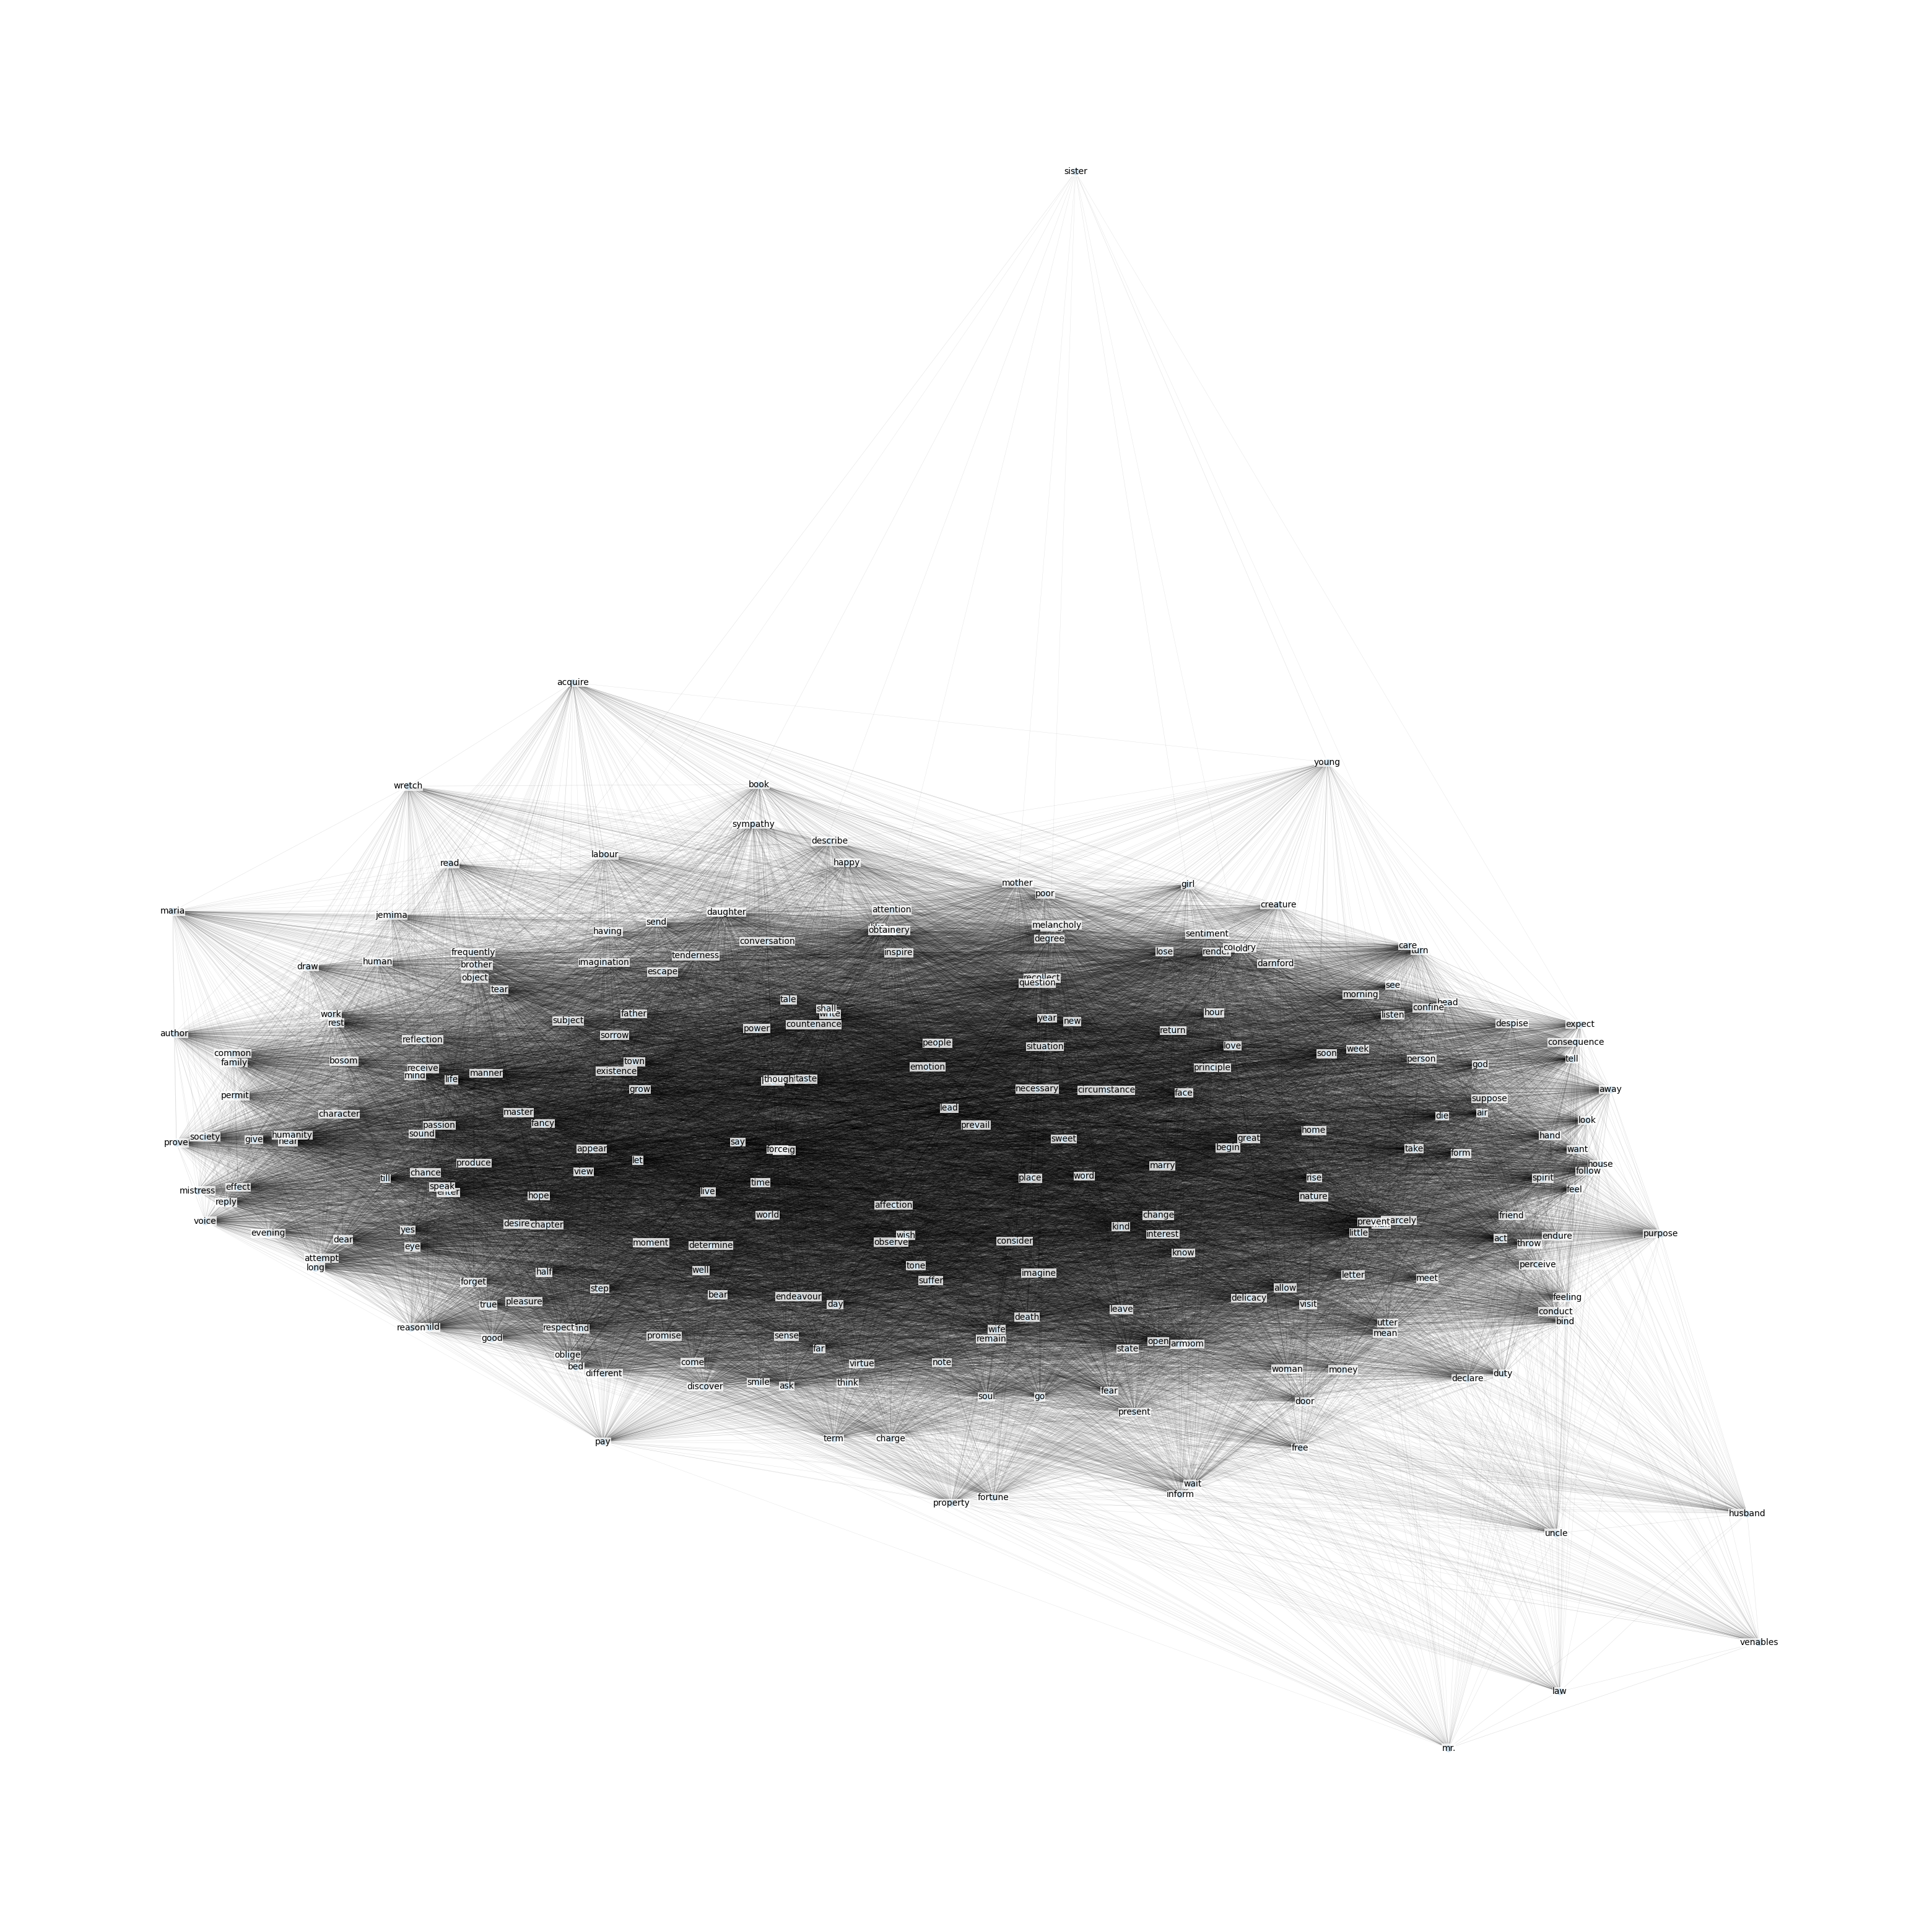

In [82]:
draw_similarity_network(maria_network, savepath="../outputs/wollstonecraft-maria-similarity-network")

## Topic Modeling

There is one more important approach to deriving key term clusters from texts. Topic modeling is a way of searching through a series of texts for clusters of words that both recur in some texts and distinguish those groups from others. It is not best applied to entire novels, unless one is working with a large corpus of novels. At the single-novel level, it is best applied to segments like chapters or even paragraphs of a chapter. Here, we will try it on the chapters of *Maria*. 

We'll use Latent Dirichlet Allocation (LDA), a technique that uses unsupervised machine learning to discover groups of words that frequently co-occur in multiple documents across a corpus.

We'll import the CountVectorizer class from the scikit-learn library. This will convert text data into numerical vectors, then count the frequency of words in any given document and convert all the data into a matrix where each word is a column and each row is a document, and the cell contains the frequency of that word in that document.

We'll then instantiate a CountVectorizer. We'll specify a max_df of 0.7, which means we want to ignore words that appear in over 70% of the corpus. We specify a min_df of 2, which means we want words that appear in at least 2 texts. We also specify it should ignore English stop words.

In [83]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_df=0.7, min_df=2, stop_words='english')

Next, we'll prepare the data for analysis. To do that, we'll take our chapters dictionary and convert it into a pandas data frame. Additionally, the "Maria" and "Preface" sections would throw off the analysis, so we'll eliminate them.

In [84]:
maria_chapters_df = pd.DataFrame.from_dict(maria_contents, orient='index', columns=['content'])
maria_chapters_df = maria_chapters_df.drop(['MARIA', 'PREFACE'])

In [85]:
maria_chapters_df

,content
AUTHOR’S PREFACE,"AUTHOR’S PREFACE The wrongs of woman, like the..."
CHAPTER 1,CHAPTER 1 Abodes of horror have frequently bee...
CHAPTER 2,CHAPTER 2 Earnestly as Maria endeavoured to so...
CHAPTER 3,CHAPTER 3 When perusing the first parcel of bo...
CHAPTER 4,"CHAPTER 4 Pity, and the forlorn seriousness of..."
CHAPTER 5,"CHAPTER 5 “My father,” said Jemima, “seduced m..."
CHAPTER 6,CHAPTER 6 Active as love was in the heart of M...
CHAPTER 7,"CHAPTER 7 “Addressing these memoirs to you, my..."
CHAPTER 8,CHAPTER 8 “I have perhaps dwelt too long on a ...
CHAPTER 9,CHAPTER 9 “I resume my pen to fly from thought...


Now we'll actually run the topic modeling algorithm. 
- Create the document term matrix. Here the count vectorizer looks through the text of each chapter, counts the occurrences of each word, and sets up the results as a matrix (`dtm = cv.fit_transform(maria_chapters_df['content'])`).
- Create a Latent Dirichlet Allocation object. Here we set the number of topics we are looking for, as well as an initial random state. Without setting the random state, the results will be different every time the algorithm runs (`LDA = LatentDirichletAllocation(n_components=2, random_state=42)`).
- I set a very low number of topics because we have a very low number of texts.
- The LDA algorithm examins the document term matrix to find patterns of word distributions and similarities among chapters (`LDA.fit(dtm)`).
- We get the probabilities that any given text will pertain to any given topic (`topic_results = LDA.transform(dtm)`).
- We assign the topic with the highest probability to each chapter (`maria_chapters_df['Topic'] = topic_results.argmax(axis=1) + 1`).
- We loop over the chapters, outputting the results to the screen. This is looking at the learned topic-word matrix (LDA.components_) and extracting the top 20 words for each word cluster.
- We build a dictionary of topic word clusters.
- We add the topic words to our data frame so we can inspect it.

In [86]:
dtm = cv.fit_transform(maria_chapters_df['content'])
from sklearn.decomposition import LatentDirichletAllocation
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(dtm)

topic_results = LDA.transform(dtm)
maria_chapters_df['Topic'] = topic_results.argmax(axis=1) + 1

for i, topic in enumerate(LDA.components_):
    print(f"THE TOP 20 WORDS FOR TOPIC # {i}")
    print([cv.get_feature_names_out()[index] for index in topic.argsort()[-20:]])
    print('\n')
    print('\n')

topic_word_dict = {}

feature_names = cv.get_feature_names_out()

for i, topic in enumerate(LDA.components_):

    top_words = [
        feature_names[index]
        for index in topic.argsort()[-20:][::-1]
    ]

    topic_word_dict[i + 1] = top_words

maria_chapters_df['Topic Words'] = (
    maria_chapters_df['Topic']
    .map(topic_word_dict)
)

maria_chapters_df

THE TOP 20 WORDS FOR TOPIC # 0
['tenderness', 'friend', 'place', 'conduct', 'great', 'pleasure', 'feelings', 'jemima', 'darnford', 'country', 'children', 'came', 'woman', 'brother', 'mr', 'man', 'venables', 'maria', 'uncle', 'father']




THE TOP 20 WORDS FOR TOPIC # 1
['wished', 'opened', 'anguish', 'place', 'long', 'waited', 'thee', 'know', 'night', 'countenance', 'leave', 'arms', 'sound', 'scarcely', 'day', 'door', 'babe', 'maria', 'darnford', 'jemima']




THE TOP 20 WORDS FOR TOPIC # 2
['darnford', 'conduct', 'men', 'father', 'uncle', 'home', 'gave', 'began', 'reason', 'human', 'state', 'poor', 'situation', 'venables', 'society', 'mr', 'jemima', 'man', 'woman', 'maria']






,content,Topic,Topic Words
AUTHOR’S PREFACE,"AUTHOR’S PREFACE The wrongs of woman, like the...",3,"[maria, woman, man, jemima, mr, society, venab..."
CHAPTER 1,CHAPTER 1 Abodes of horror have frequently bee...,3,"[maria, woman, man, jemima, mr, society, venab..."
CHAPTER 2,CHAPTER 2 Earnestly as Maria endeavoured to so...,3,"[maria, woman, man, jemima, mr, society, venab..."
CHAPTER 3,CHAPTER 3 When perusing the first parcel of bo...,3,"[maria, woman, man, jemima, mr, society, venab..."
CHAPTER 4,"CHAPTER 4 Pity, and the forlorn seriousness of...",1,"[father, uncle, maria, venables, man, mr, brot..."
CHAPTER 5,"CHAPTER 5 “My father,” said Jemima, “seduced m...",3,"[maria, woman, man, jemima, mr, society, venab..."
CHAPTER 6,CHAPTER 6 Active as love was in the heart of M...,2,"[jemima, darnford, maria, babe, door, day, sca..."
CHAPTER 7,"CHAPTER 7 “Addressing these memoirs to you, my...",1,"[father, uncle, maria, venables, man, mr, brot..."
CHAPTER 8,CHAPTER 8 “I have perhaps dwelt too long on a ...,1,"[father, uncle, maria, venables, man, mr, brot..."
CHAPTER 9,CHAPTER 9 “I resume my pen to fly from thought...,3,"[maria, woman, man, jemima, mr, society, venab..."


To make it easier to look at the results, I'm going to drop the chapter texts and create an HTML version in which I can see all the topic words.

In [87]:
maria_chapters_with_topics = maria_chapters_df.drop(['content'], axis=1)

In [88]:
from IPython.core.display import HTML
display(HTML(maria_chapters_with_topics.to_html()))

,Topic,Topic Words
AUTHOR’S PREFACE,3,"[maria, woman, man, jemima, mr, society, venables, situation, poor, state, human, reason, began, gave, home, uncle, father, men, conduct, darnford]"
CHAPTER 1,3,"[maria, woman, man, jemima, mr, society, venables, situation, poor, state, human, reason, began, gave, home, uncle, father, men, conduct, darnford]"
CHAPTER 2,3,"[maria, woman, man, jemima, mr, society, venables, situation, poor, state, human, reason, began, gave, home, uncle, father, men, conduct, darnford]"
CHAPTER 3,3,"[maria, woman, man, jemima, mr, society, venables, situation, poor, state, human, reason, began, gave, home, uncle, father, men, conduct, darnford]"
CHAPTER 4,1,"[father, uncle, maria, venables, man, mr, brother, woman, came, children, country, darnford, jemima, feelings, pleasure, great, conduct, place, friend, tenderness]"
CHAPTER 5,3,"[maria, woman, man, jemima, mr, society, venables, situation, poor, state, human, reason, began, gave, home, uncle, father, men, conduct, darnford]"
CHAPTER 6,2,"[jemima, darnford, maria, babe, door, day, scarcely, sound, arms, leave, countenance, night, know, thee, waited, long, place, anguish, opened, wished]"
CHAPTER 7,1,"[father, uncle, maria, venables, man, mr, brother, woman, came, children, country, darnford, jemima, feelings, pleasure, great, conduct, place, friend, tenderness]"
CHAPTER 8,1,"[father, uncle, maria, venables, man, mr, brother, woman, came, children, country, darnford, jemima, feelings, pleasure, great, conduct, place, friend, tenderness]"
CHAPTER 9,3,"[maria, woman, man, jemima, mr, society, venables, situation, poor, state, human, reason, began, gave, home, uncle, father, men, conduct, darnford]"


I don't find the results too highly illuminating. Topic 1 seems to be about feelings, pleasure, friendship, tenderness, children, family. Topic 2 seems to be about angish, desire, waiting, and the passage of time. Topic 3 seems to have to do with men, women, society, conduct, and reasoning about the poor state of humanity. Perhaps topic 1 is the pleasant feelings to be had in family, topic 2 is about the painful feelings having to do with waiting and wanting, topic 3 has to do with the proper conduct of relations between men and women in society.

I suspect LDA will be more useful at larger scales.

I will also point out that I am getting extremely common words like "maria", "man", and "woman" even though I set max_df at 0.7. It would be useful to analyze and evaluate why this happened and potentially tinker with the max_df so as to ensure that LDA actually finds useful patterns, which in this case it did not.

## KWIC Disgust

Critics have noted that Mary Wollstonecraft has an elaborate vocabulary of disgust (Laura Kirkley, Mary Wollstonecraft: Cosmopolitan. Edinburgh University Press, 2022, pp. 16, 93-4). Laura Kirkley argues that "regardless of her efforts to stake out a philanthropic ethical position, the knotty issues of self-regard and projective disgust persist at the stylistic level, her prose performing the difficulty of mustering compassion in the face of alterity" (2022, 94). What could we learn about this topic using digital methods?

We have a crowdsourced [lexicon of disgust](https://saifmohammad.com/WebPages/NRC-Emotion-Lexicon.htm) which we could use to fish for words of disgust in Wollestonecraft's oeuvre. Let's start with one of the funner outputs we've looked at so far, the word cloud.

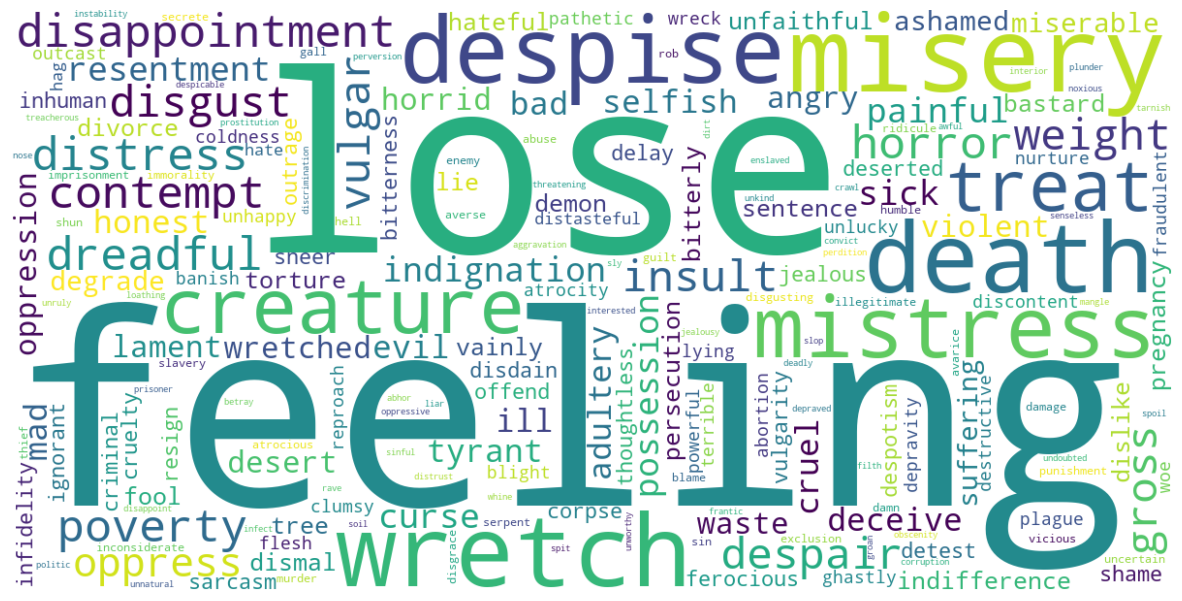

In [89]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load fear lexicon
disgust_words = set()

with open("disgust-NRC-Emotion-Lexicon.txt", "r", encoding="utf-8") as f:
    for line in f:
        word, label = line.strip().split("\t")

        if label == "1":
            disgust_words.add(word.lower())

# Count lemmas 
lemma_counts = Counter()

for token in maria_doc:
    if (
        not token.is_punct
        and not token.is_space
        and not token.is_stop
    ):
        lemma = token.lemma_.lower()
        lemma_counts[lemma] += 1

disgust_counts = {
    lemma: count
    for lemma, count in lemma_counts.items()
    if lemma in disgust_words
}

# Generate word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)

wc.generate_from_frequencies(disgust_counts)

plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.savefig(
        f"maria_disgust_words.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()

I find this rather interesting. In particular, I'm seeing some similarities with the corresponding word clouds for negative emotions in Frankenstein, including the prominent use of the terms "wretch" and "creature" as well as the centrality of the word "feeling". 

Let's get some more numeric statistics. First I'll take our list of disgust-coded words and their counts in the text, and I'll sort them by number of appearances and then alphabetically.

In [104]:
sorted_disgust_counts = dict(sorted(disgust_counts.items(), key=lambda x: (-x[1], x[0])))
sorted_disgust_counts

{'feeling': 30,
 'lose': 26,
 'misery': 25,
 'wretch': 22,
 'death': 21,
 'despise': 19,
 'mistress': 19,
 'creature': 17,
 'treat': 14,
 'contempt': 10,
 'disappointment': 10,
 'distress': 10,
 'dreadful': 10,
 'horror': 10,
 'poverty': 10,
 'despair': 9,
 'disgust': 9,
 'gross': 9,
 'insult': 9,
 'vulgar': 9,
 'weight': 9,
 'curse': 8,
 'indignation': 8,
 'oppress': 8,
 'painful': 8,
 'possession': 8,
 'resentment': 8,
 'sick': 8,
 'adultery': 7,
 'bad': 7,
 'cruel': 7,
 'deceive': 7,
 'evil': 7,
 'honest': 7,
 'ill': 7,
 'mad': 7,
 'selfish': 7,
 'tyrant': 7,
 'angry': 6,
 'desert': 6,
 'horrid': 6,
 'lament': 6,
 'oppression': 6,
 'violent': 6,
 'waste': 6,
 'wretched': 6,
 'ashamed': 5,
 'degrade': 5,
 'miserable': 5,
 'suffering': 5,
 'bastard': 4,
 'bitterly': 4,
 'demon': 4,
 'dislike': 4,
 'dismal': 4,
 'divorce': 4,
 'fool': 4,
 'hateful': 4,
 'indifference': 4,
 'lie': 4,
 'persecution': 4,
 'pregnancy': 4,
 'sentence': 4,
 'torture': 4,
 'tree': 4,
 'unfaithful': 4,
 'vainl

In [91]:
# def top_n_words(emotion_dict, n=20):
#     return sorted(
#         emotion_dict.items(),
#         key=lambda item: item[1],
#         reverse=True
#     )[:n]

Next, I'm going to create a method to get the top 20 terms, except if there is a tie that takes the number of terms to more than 20, it should return all the tied items. For example, in this case if you get the top 20 emotion terms for disgust, that takes us up to words that occur 9 times in the novel. But if we restrict ourselves to just 20, we have to randomly leave out one of the words that occurs 9 times. So in this case we want to get 21 terms so we get all the words that occur 9 times.

In [105]:
def top_n_words(emotion_dict, n=20):
    sorted_items = sorted(
        emotion_dict.items(),
        key=lambda item: (-item[1], item[0])
    )
    if len(sorted_items) <= n:
        return sorted_items
    
    cutoff_value = sorted_items[n - 1][1]
    extra = [item for item in sorted_items[n:] if item[1] == cutoff_value]
    
    return sorted_items[:n] + extra

In [110]:
top_disgust_words = top_n_words(disgust_counts)
top_disgust_words

[('feeling', 30),
 ('lose', 26),
 ('misery', 25),
 ('wretch', 22),
 ('death', 21),
 ('despise', 19),
 ('mistress', 19),
 ('creature', 17),
 ('treat', 14),
 ('contempt', 10),
 ('disappointment', 10),
 ('distress', 10),
 ('dreadful', 10),
 ('horror', 10),
 ('poverty', 10),
 ('despair', 9),
 ('disgust', 9),
 ('gross', 9),
 ('insult', 9),
 ('vulgar', 9),
 ('weight', 9)]

The method returns a list of tuples with each word and its frequency listed.. I'm going to turn it into a simple list of words. Then I'll use a simple script using the spacy pattern matcher to see very occurrence of those words in the novel.

In [111]:
disgust_list = [el[0] for el in top_disgust_words]
disgust_list

['feeling',
 'lose',
 'misery',
 'wretch',
 'death',
 'despise',
 'mistress',
 'creature',
 'treat',
 'contempt',
 'disappointment',
 'distress',
 'dreadful',
 'horror',
 'poverty',
 'despair',
 'disgust',
 'gross',
 'insult',
 'vulgar',
 'weight']

In [112]:
from spacy.matcher import Matcher

matcher = Matcher(nlp.vocab)

pattern = [{"LEMMA": {"IN": disgust_list}}]

matcher.add("DISGUST", [pattern])

matches = matcher(maria_doc)

for match_id, start, end in matches:
    print(maria_doc[start-20:end+20])
    print('------------------')

made the incidents more dramatic, would
I have sacrificed my main object, the desire of exhibiting the misery
and oppression, peculiar to women, that arise out of the partial laws
and customs of society
------------------
, lest her
perception of grace and refinement of sentiment, should sharpen to
agony the pangs of disappointment. Love, in which the imagination
mingles its bewitching colouring, must be fostered by delicacy. I
------------------
, in which the imagination
mingles its bewitching colouring, must be fostered by delicacy. I
should despise, or rather call her an ordinary woman, who could endure
such a husband as I have sketched
------------------
oppressive, though, from the difference of education, necessarily
various.




CHAPTER 1


Abodes of horror have frequently been described, and castles, filled
with spectres and chimeras, conjured up by the magic
------------------
But, formed of such
stuff as dreams are made of, what were they to the mansion of despair,
in one co

The previous script generated a KWIC analysis showing the 20 characters before and after the disgust word. I may be more interested in the sentences they are in. This script shows all the sentences in Maria that contain a disgust word. This uses lemmatized matching.

In [94]:
matches = matcher(maria_doc)
matching_sentences = {}
for match_id, start, end in matches:
    sentence = maria_doc[start].sent
    label = nlp.vocab.strings[match_id]
    if sentence not in matching_sentences:
        matching_sentences[sentence] = {"DISGUST": False}
    matching_sentences[sentence][label] = True

In [95]:
for sentence, emotion in matching_sentences.items():
    if emotion["DISGUST"]:
        print(sentence)
        print('----------------------')


In many instances I could have made the incidents more dramatic, would
I have sacrificed my main object, the desire of exhibiting the misery
and oppression, peculiar to women, that arise out of the partial laws
and customs of society.


----------------------
For my part, I cannot suppose any situation more distressing, than for
a woman of sensibility, with an improving mind, to be bound to such a
man as I have described for life; obliged to renounce all the
humanizing affections, and to avoid cultivating her taste, lest her
perception of grace and refinement of sentiment, should sharpen to
agony the pangs of disappointment.
----------------------
I
should despise, or rather call her an ordinary woman, who could endure
such a husband as I have sketched.


----------------------
CHAPTER 1


Abodes of horror have frequently been described, and castles, filled
with spectres and chimeras, conjured up by the magic spell of genius to
harrow the soul, and absorb the wondering mind.
----------

Now I'm going to generate a data frame. I'll generate this method, `extract_emotion_matches`. It accepts a dictionary of texts -- in this case the chapters of Maria, but it could be any texts. It accepts a Spacy matcher, and a Spacy language model. It then goes through the list of texts, lemmatizes them, and extracts all the pattern matches. It finds the sentences within which those matches exist and writes a data frame in which the columns inc lude the name of the text (the key to the dictionary entry for that text); the pattern label (in this case, an emotion, disgust, but there could be multiple patterns); the lemma found; the sentence; and the beginning and ending character count, that is, the location of that sentence in the text.

In [96]:
def extract_emotion_matches(chapters_dict, matcher, nlp):
    match_data = []

    for chapter_number, chapter_text in chapters_dict.items():
        doc = nlp(chapter_text)
        matches = matcher(doc)

        for match_id, start, end in matches:
            span = doc[start:end]
            sentence = span.sent
            label = nlp.vocab.strings[match_id]
            lemma = span[0].lemma_
            cleaned_sentence = " ".join(sentence.text.strip().split())

            match_data.append({
                "chapter": chapter_number,
                "emotion": label,
                "lemma": lemma,
                "sentence": cleaned_sentence,
                "sentence_start_char": sentence.start_char,
                "sentence_end_char": sentence.end_char,
            })

    return pd.DataFrame(match_data)

In [97]:
all_disgust_words = list(disgust_counts.keys())

In [98]:
all_disgust_words

['discrimination',
 'oppress',
 'abortion',
 'misery',
 'oppression',
 'disappointment',
 'despise',
 'despotism',
 'degrade',
 'oppressive',
 'horror',
 'despair',
 'indignation',
 'groan',
 'dreadful',
 'torture',
 'unhappy',
 'lament',
 'ill',
 'atrocity',
 'depravity',
 'resign',
 'contempt',
 'selfish',
 'tyrant',
 'possession',
 'resentment',
 'outrage',
 'feeling',
 'insult',
 'indifference',
 'clumsy',
 'horrid',
 'rave',
 'mad',
 'disgust',
 'ghastly',
 'convict',
 'betray',
 'fool',
 'banish',
 'deadly',
 'blight',
 'weight',
 'perdition',
 'offend',
 'deceive',
 'painful',
 'evil',
 'perversion',
 'suffering',
 'wretched',
 'vulgar',
 'infect',
 'plague',
 'outcast',
 'interested',
 'discontent',
 'flesh',
 'bitterness',
 'woe',
 'cruel',
 'lose',
 'creature',
 'desert',
 'nurture',
 'fraudulent',
 'wretch',
 'instability',
 'noxious',
 'destructive',
 'unfaithful',
 'bitterly',
 'frantic',
 'mangle',
 'corpse',
 'angry',
 'wreck',
 'politic',
 'enslaved',
 'treacherous',
 '

In [99]:
matcher.remove("DISGUST")

In [100]:
disgust_pattern = [{"LEMMA": {"IN": all_disgust_words}}]

matcher.add("DISGUST", [disgust_pattern])

matches = matcher(maria_doc)

In [101]:
disgust_df = extract_emotion_matches(maria_contents, matcher, nlp)

In [102]:
pd.set_option('display.max_colwidth', None)

In [103]:
disgust_df

,chapter,emotion,lemma,sentence,sentence_start_char,sentence_end_char
0,PREFACE,DISGUST,discrimination,"PREFACE The public are here presented with the last literary attempt of an author, whose fame has been uncommonly extensive, and whose talents have probably been most admired, by the persons by whom talents are estimated with the greatest accuracy and discrimination.",0,267
1,AUTHOR’S PREFACE,DISGUST,oppress,"The wrongs of woman, like the wrongs of the oppressed part of mankind, may be deemed necessary by their oppressors: but surely there are a few, who will dare to advance before the improvement of the age, and grant that my sketches are not the abortion of a distempered fancy, or the strong delineations of a wounded heart.",17,339
2,AUTHOR’S PREFACE,DISGUST,abortion,"The wrongs of woman, like the wrongs of the oppressed part of mankind, may be deemed necessary by their oppressors: but surely there are a few, who will dare to advance before the improvement of the age, and grant that my sketches are not the abortion of a distempered fancy, or the strong delineations of a wounded heart.",17,339
3,AUTHOR’S PREFACE,DISGUST,misery,"In many instances I could have made the incidents more dramatic, would I have sacrificed my main object, the desire of exhibiting the misery and oppression, peculiar to women, that arise out of the partial laws and customs of society.",424,658
4,AUTHOR’S PREFACE,DISGUST,oppression,"In many instances I could have made the incidents more dramatic, would I have sacrificed my main object, the desire of exhibiting the misery and oppression, peculiar to women, that arise out of the partial laws and customs of society.",424,658
...,...,...,...,...,...,...
849,CONCLUSION,DISGUST,misery,"It was particularly the design of the author, in the present instance, to make her story subordinate to a great moral purpose, that “of exhibiting the misery and oppression, peculiar to women, that arise out of the partial laws and customs of society.—This view restrained her fancy.",5079,5362
850,CONCLUSION,DISGUST,oppression,"It was particularly the design of the author, in the present instance, to make her story subordinate to a great moral purpose, that “of exhibiting the misery and oppression, peculiar to women, that arise out of the partial laws and customs of society.—This view restrained her fancy.",5079,5362
851,CONCLUSION,DISGUST,evil,"It was necessary for her, to place in a striking point of view, evils that are too frequently overlooked, and to drag into light those details of oppression, of which the grosser and more insensible part of mankind make little account.",5368,5603
852,CONCLUSION,DISGUST,oppression,"It was necessary for her, to place in a striking point of view, evils that are too frequently overlooked, and to drag into light those details of oppression, of which the grosser and more insensible part of mankind make little account.",5368,5603


This can now be exported to an Excel spreadsheet. Now, as one close-reads the text, one could pause to focus on the occurrences of disgust words. One could do this for several other realms of emotion using the emotion lexicons. One can also quickly find all instances of specific words one is interested in.

In [116]:
# disgust_df.to_excel('../outputs/maria_disgust.xlsx', sheet_name='maria_disgust_sentences')